In [1]:
import numpy as np
import pandas as pd
from math import *
#scipy stat

from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
import matplotlib.pyplot as plt
import seaborn as sns
###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.stats.anova import anova_lm
from statsmodels.regression.linear_model import OLS
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust.norms import LeastSquares, HuberT, RamsayE, AndrewWave, TukeyBiweight,\
    TrimmedMean, Hampel
from statsmodels.stats.outliers_influence import OLSInfluence,variance_inflation_factor
from statsmodels.stats import stattools

from statsmodels.graphics.gofplots import qqplot_2samples,qqplot
from statsmodels.graphics.plot_grids import scatter_ellipse
from statsmodels.graphics.regressionplots import influence_plot, plot_leverage_resid2

from patsy import dmatrices,dmatrix

###################################################
'''sklearn'''
###################################################

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler                         
# linear_model
from sklearn.linear_model import Ridge,RidgeCV

#decomposition
from sklearn.decomposition import PCA
import os



#### About Dataset:

- mpg → Miles per gallon (target variable)
- cylinders → Number of cylinders in the engine
- displacement → Engine displacement (cubic inches)
- horsepower → Engine horsepower (note: some values may be non‑numeric or missing)
- weight → Vehicle weight (lbs)
- acceleration → Time to accelerate from 0–60 mph (seconds)
- model year → Year of manufacture (70–82)
- origin → Origin of car (1 = USA, 2 = Europe, 3 = Japan)
- car name → String identifier of the car mode

Continuous Variables
These are measured on a scale and can take many values:
- mpg (miles per gallon)
- displacement (engine size)
- horsepower (engine power)
- weight (vehicle weight)
- acceleration (0–60 mph time)

Discrete / Categorical Variables
These are categories or counts:
- cylinders (number of cylinders: 3, 4, 5, 6, 8)
- model year (treated as discrete, though numeric)
- origin (USA, Europe, Japan)


#### 1. Get Data and Apply Data cleaning

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/Auto-mpg dataset/auto-mpg.csv'):
    for filename in filenames:
        path = os.path.join(dirname, filename)
        print(path)
path = "/kaggle/input/datasets/organizations/uciml/autompg-dataset/auto-mpg.csv"
# Replace with the actual path printed above
df = pd.read_csv(path)

# Preview the data
print(df.head())

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

    mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [3]:
# 1. Check for null values
print("Null values per column:")
print(df.isnull().sum())

# 2. Check if any nulls are present at all
print("\nAny nulls present in dataset?:", df.isnull().values.any())

# 3. Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

# 4. Show duplicate rows (if any)
duplicates = df[df.duplicated()]
print("\nDuplicate rows:")
print(duplicates)

# 5. Dataset info (structure, dtypes, non-null counts)
print("\nDataset Info:")
print(df.info())

# 6. Quick summary statistics
print("\nSummary statistics:")
print(df.describe())

# Check if all rows are unique
all_unique = not df.duplicated().any()

print("Are all rows unique?", all_unique)

# If not unique, show duplicate rows
if not all_unique:
    duplicates = df[df.duplicated()]
    print("\nDuplicate rows:")
    print(duplicates)


Null values per column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Any nulls present in dataset?: False

Number of duplicate rows: 0

Duplicate rows:
Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model year, origin, car name]
Index: []

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    obj

No nulls detected across all 9 columns. This means the dataset is complete and doesn’t require imputation for missing values. No duplicate rows found. Every entry (car record) is unique, so no need for deduplication.

- Numeric: mpg, cylinders, displacement, weight, acceleration, model year, origin
- Object (string): horsepower, car name

- mpg: Mean ≈ 23.5, range 9 → 46.6
- cylinders: Mostly 4, but ranges 3 → 8
- displacement: Mean ≈ 193, range 68 → 455
- weight: Mean ≈ 2970 lbs, range 1613 → 5140
- acceleration: Mean ≈ 15.6 sec, range 8 → 24.8
- model year: 1970 → 1982
- origin: 1 (USA), 2 (Europe), 3 (Japan)

Dataset is clean and complete, but horsepower needs preprocessing. Strong variation in $mpg$, $displacement$, and $weight$ makes this dataset ideal for regression analysis. $origin$ is categorical and should be encoded (e.g., one-hot encoding) for modeling. *car nam*e is text and usually dropped or used for feature engineering (e.g., extracting brand).

#### 1.1 Clean horsepower column

The horsepower column contains entries marked as "?" instead of numeric values. Because of the "?" entries, the entire column is often read as string/object type instead of numeric. Cleaning the horsepower column ensures it is numeric, consistent, and complete, which is critical for regression analysis. Without cleaning, your models would either fail to run or produce biased results.

In [4]:
# Clean horsepower column
df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")
df = df.dropna(subset=["horsepower"])

#### 1.2 Map origin values to labels

In [5]:
# Map origin values to labels
origin_map = {1: "Japan", 2: "Europe", 3: "USA"}
df["origin_label"] = df["origin"].map(origin_map)

# Encode origin_label as numeric for regression
df["origin_code"] = df["origin_label"].astype("category").cat.codes

#### 2. Computes correlation and covariance matrices for the numerical variables in the Auto-MPG dataset

Covariance and correlation matrices both measure the linear relationship between variables, but they differ primarily in standardization. A covariance matrix uses the original units of the data, while a correlation matrix is a scaled version that normalizes these values into a range from -1 to +1, making them easier to interpret and compare across different datasets.

Covariance Matrix:

Measures how two variables change together. If one increases while the other increases, the covariance is positive; if they move in opposite directions, it is negative.

$Cov(X,X)=Var(X)$ 

Correlation Matrix:

A standardized form of the covariance matrix where each entry is the Pearson's correlation coefficient.
It is calculated by dividing the covariance of two variables by the product of their standard deviations: 

$r(X,Y)=\frac{Cov(X,Y)}{\sigma X\cdot \sigma Y}$.

Conversion between Matrices

convert a covariance matrix $\Sigma$ into a correlation matrix $\rho$ by using a diagonal matrix $D$ containing the square roots of the diagonal elements of the covariance matrix (the standard deviations).

$\rho =D^{-1}\Sigma D^{-1}$

#### 2.1 Correlation/Covariance Heatmap:

1. $Covariance$ measures the joint variability of two random variables $X$ and $Y$. 

$Cov(X,Y)=\frac{\sum _{i=1}^{n}(x_{i}-\bar{x})(y_{i}-\bar{y})}{n-1}$

This is a raw measure of how two variables change together. A *positive* value means they tend to increase at the same time, but because it’s unstandardized, a value of "100" doesn't necessarily mean a "stronger" relationship than "10" if the units (like grams vs. kilograms) are different.

2. $Correlation$ (Pearson’s $r$) Correlation standardizes covariance by dividing it by the product of the standard deviations $\sigma$ of both variables. 

$\rho _{X,Y}=\frac{Cov(X,Y)}{\sigma _{X}\sigma _{Y}}$

3. $Autocorrelation$: This is a specific type of correlation used in time-series analysis. Instead of comparing "Weight" and "Height," you compare "Stock Price Today" with "Stock Price Yesterday". It helps identify patterns like seasonality (e.g., ice cream sales peaking every 12 months).

In a time series $X_{t}$, the autocorrelation at lag $k$ is calculated by comparing $X_{t}$ with $X_{t-k}$.

 $\rho _{k}=\frac{\sum _{t=k+1}^{n}(x_{t}-\bar{x})(x_{t-k}-\bar{x})}{\sum _{t=1}^{n}(x_{t}-\bar{x})^{2}}$

Numerator: This is the Autocovariance at lag $k$.

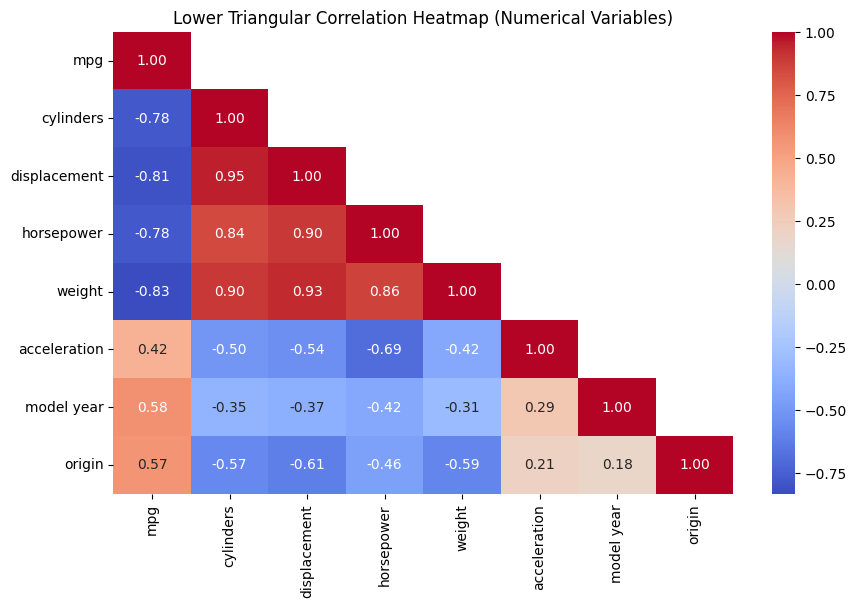

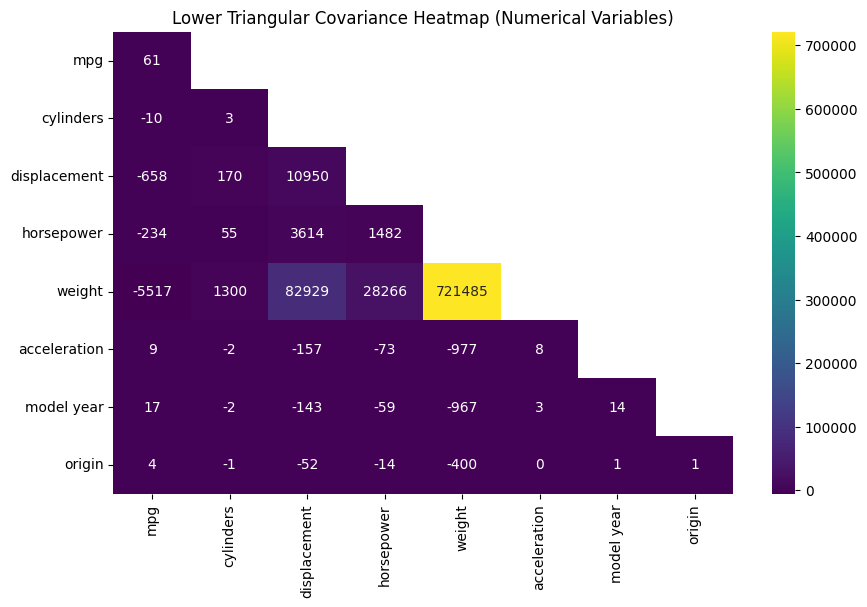

In [6]:
# Select only numerical columns
num_df = df.select_dtypes(include=['float64', 'int64'])

# --- Correlation Matrix ---
corr_matrix = num_df.corr()

# Mask for lower triangle
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, mask=~mask, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Lower Triangular Correlation Heatmap (Numerical Variables)")
plt.show()

# --- Covariance Matrix ---
cov_matrix = num_df.cov()

# Mask for lower triangle
mask = np.tril(np.ones_like(cov_matrix, dtype=bool))

plt.figure(figsize=(10, 6))
sns.heatmap(cov_matrix, mask=~mask, annot=True, cmap="viridis", fmt=".0f")
plt.title("Lower Triangular Covariance Heatmap (Numerical Variables)")
plt.show()

#### 2.2 Observations from correlation Heatmap:

##### mpg (fuel efficiency):

*Strong negative correlation* with weight (-0.83), displacement (-0.80), and cylinders (-0.78) → heavier cars with bigger engines consume more fuel. *Moderate positive correlation* with acceleration (0.42), model year (0.58), and origin (0.56) → newer cars and certain regions produced more fuel-efficient vehicles.


##### cylinders
*Very strong positive correlation* with displacement (0.95) and weight (0.90) → more cylinders usually mean larger, heavier engines. *Negative correlation* with acceleration (-0.51) and model year (-0.35) → older, cylinder-heavy cars accelerate slower and are less efficient.
##### displacement:
*Strong positive correlation* with weight (0.93) and horsepower (not shown here but typically ~0.90) → bigger engines are heavier and more powerful. *Negative correlation* with mpg (-0.80) and origin (-0.61) → larger engines reduce efficiency, and certain regions favored smaller engines.
##### weight:
*Strong negative correlation* with mpg (-0.83) → lighter cars are more efficient. *Negative correlation* with acceleration (-0.42) → heavier cars accelerate slower.
##### acceleration:
*Positive correlation* with mpg (0.42) → cars that accelerate faster tend to be more efficient.
*Negative correlation* with weight (-0.42) and displacement (-0.54) → heavier, larger cars accelerate slower.
##### model year
*Positive correlation* with mpg (0.58) → efficiency improved over time. *Negative correlation* with displacement (-0.37) and weight (-0.31) → newer cars had smaller, lighter engines.
##### origin
*Positive correlation* with mpg (0.56) → cars from certain regions (e.g., Japan) were more fuel-efficient.
*Negative correlation* with displacement (-0.61) and weight (-0.58) → those regions produced smaller, lighter cars.

Efficiency (mpg) is most strongly tied to weight, displacement, and cylinders. Engine size and car weight are tightly linked, forming the backbone of vehicle performance. Technological progress (model year) and regional design choices (origin) improved efficiency over time


#### 3. Scatter Matrix FacetGrid Plot

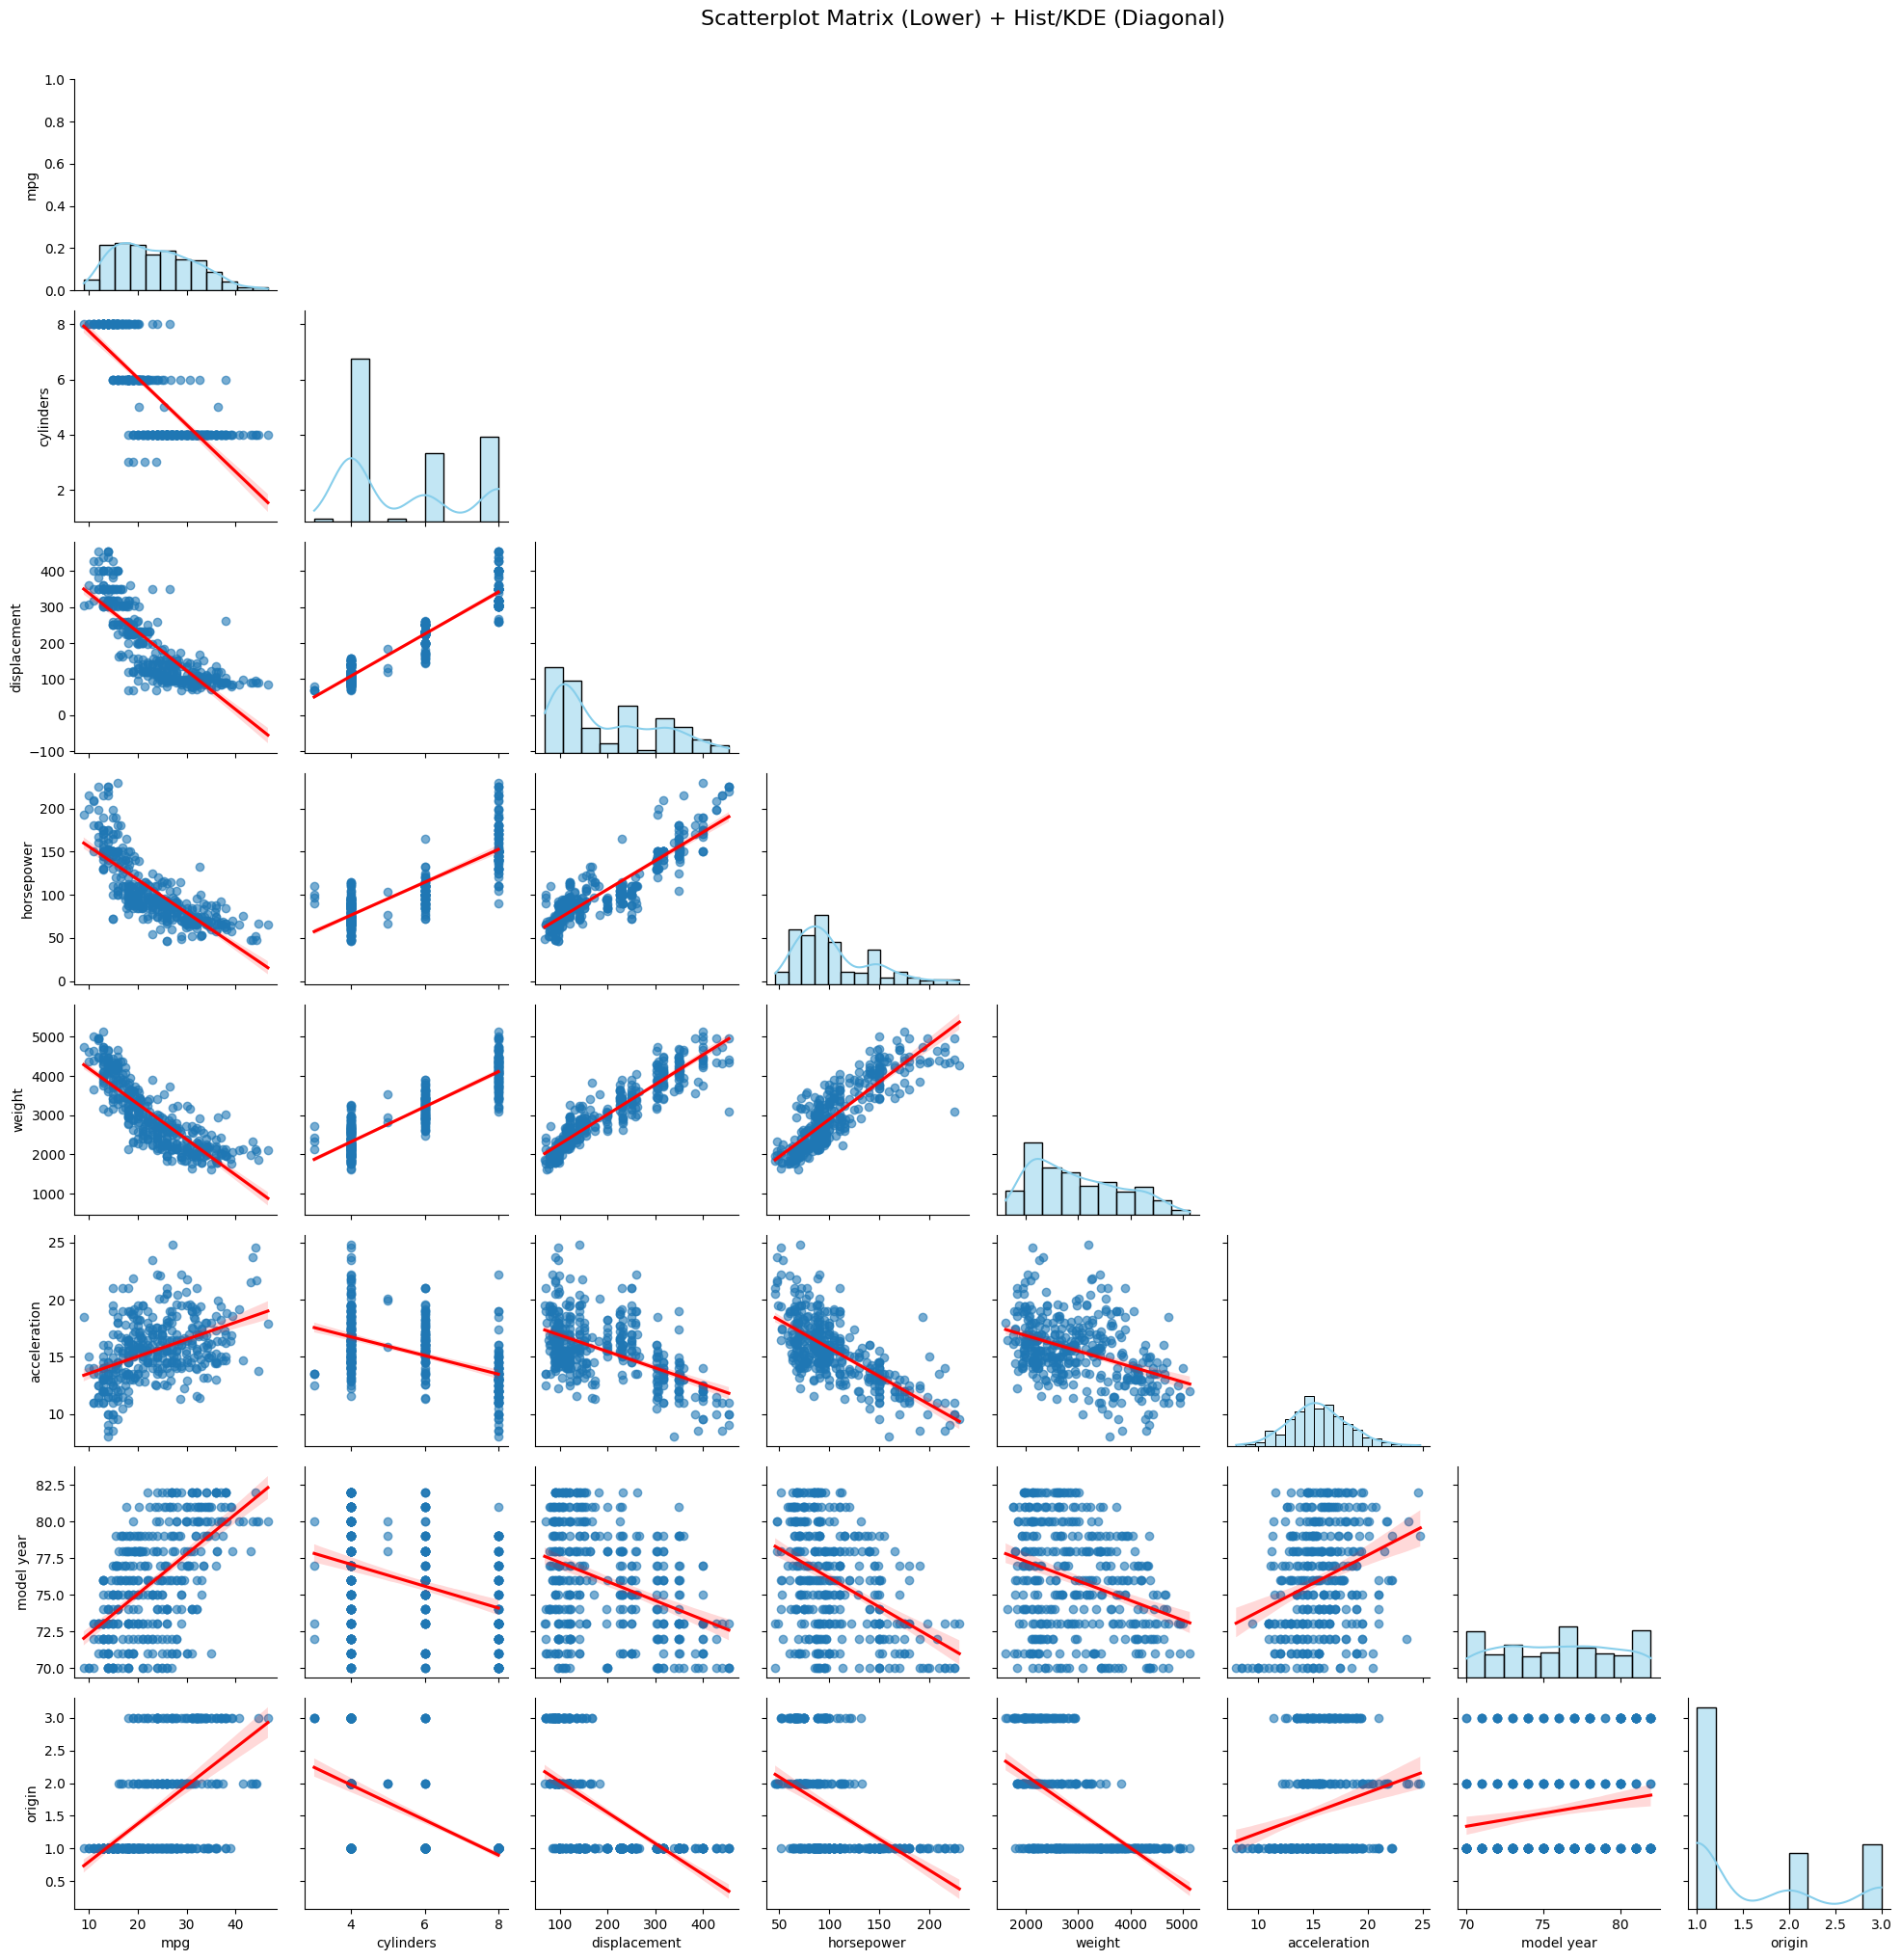

In [7]:
# Select numerical columns only
num_df = df.select_dtypes(include=['float64', 'int64'])

# Create a PairGrid
g = sns.PairGrid(num_df)

# Lower triangle: scatterplots with regression line
g.map_lower(sns.regplot, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})

# Diagonal: histogram with KDE
g.map_diag(sns.histplot, kde=True, color="skyblue")

# Upper triangle: hide (blank)
for i, j in zip(*np.triu_indices_from(g.axes, 1)):
    g.axes[i, j].set_visible(False)

plt.suptitle("Scatterplot Matrix (Lower) + Hist/KDE (Diagonal)", y=1.02, fontsize=16)
plt.show()

The scatterplot matrix highlights the core drivers of fuel efficiency (mpg) in the Auto MPG dataset.
Efficiency is most strongly negatively correlated with weight, displacement, and cylinders, showing that larger, heavier engines reduce mpg. Efficiency improves with model year and origin, reflecting technological progress and regional design choices. Engine-related variables (cylinders, displacement, horsepower, weight) are tightly interlinked, forming the backbone of vehicle performance. Overall, the matrix confirms that lighter, smaller-engine cars are more fuel-efficient, while newer models and certain regions produced vehicles with better mpg.


#### 4. Visualization shows the distribution of automobile attributes:

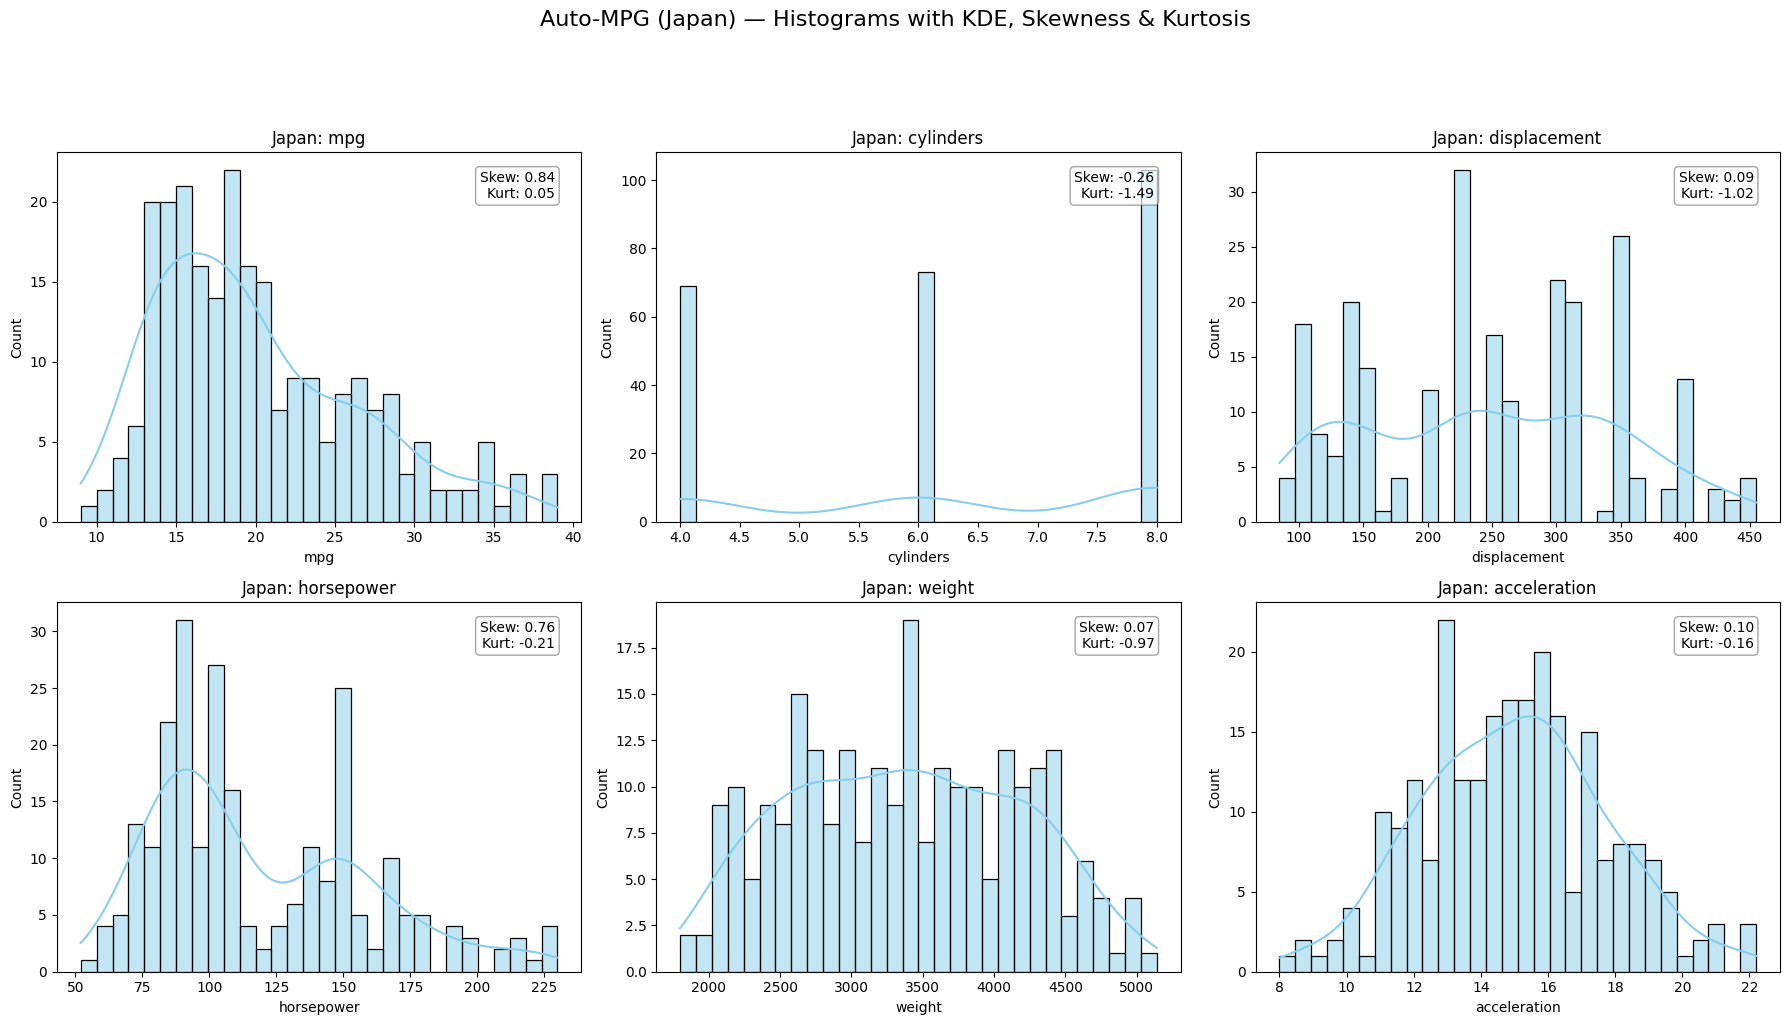

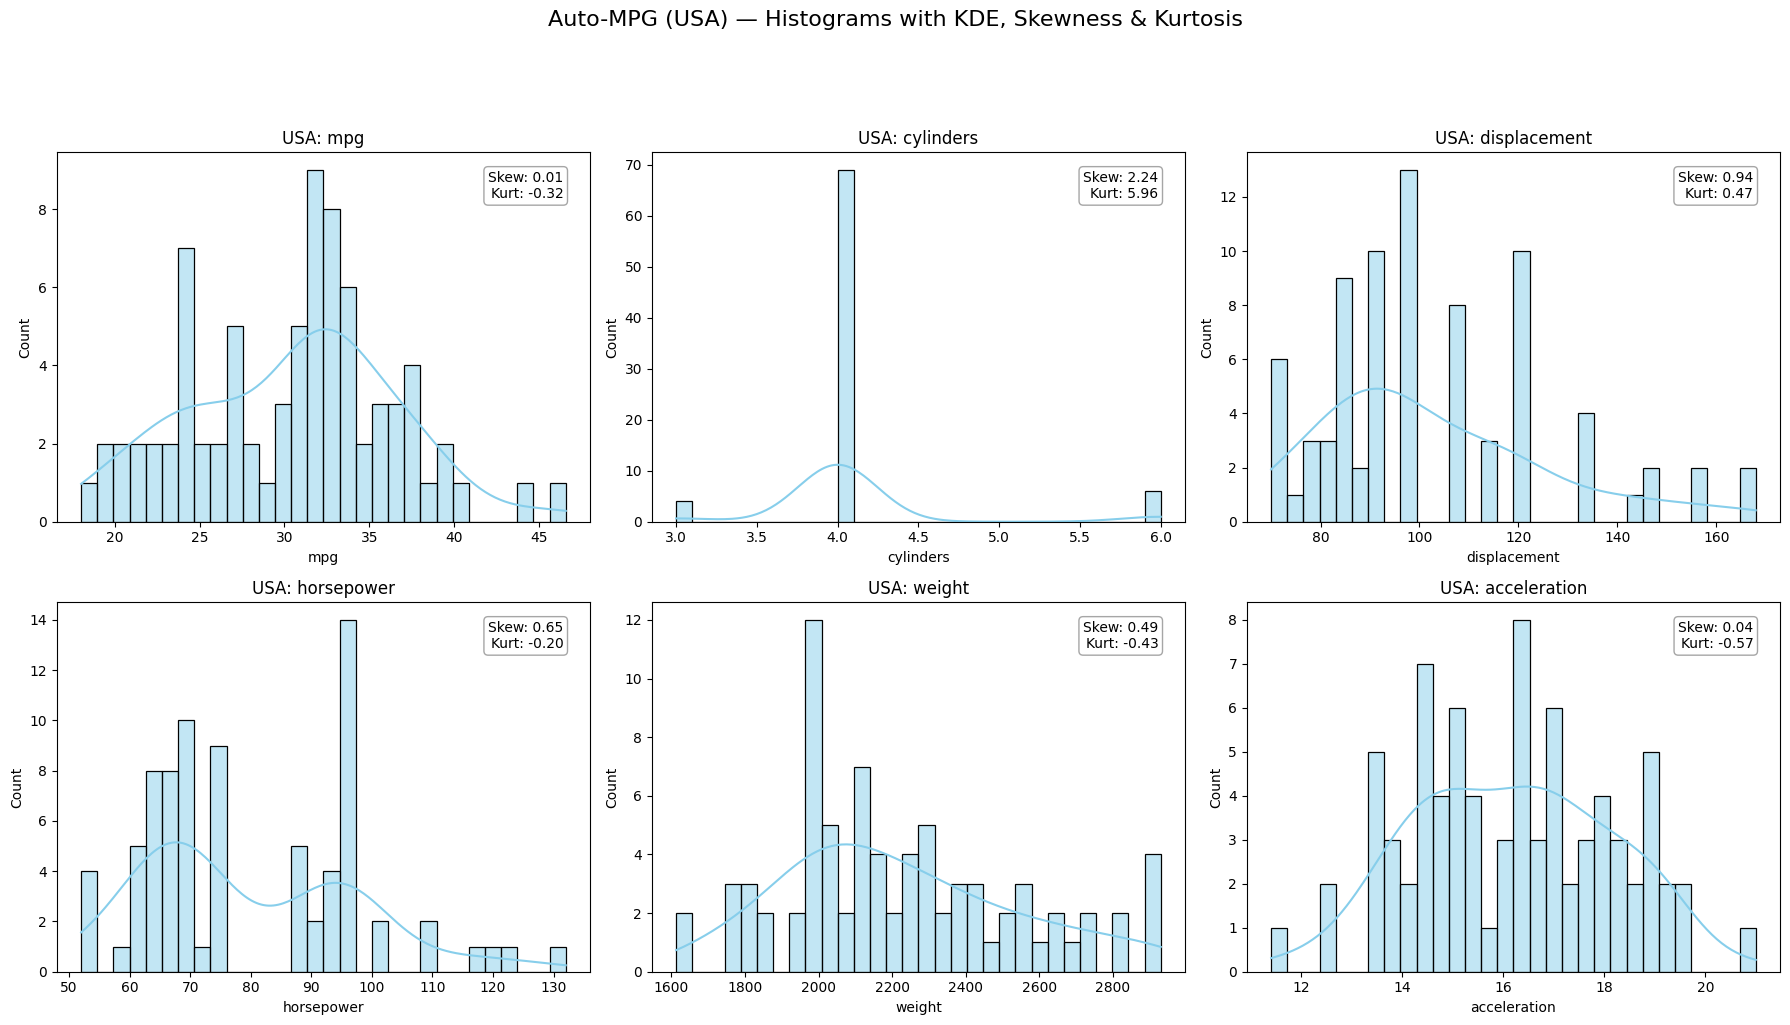

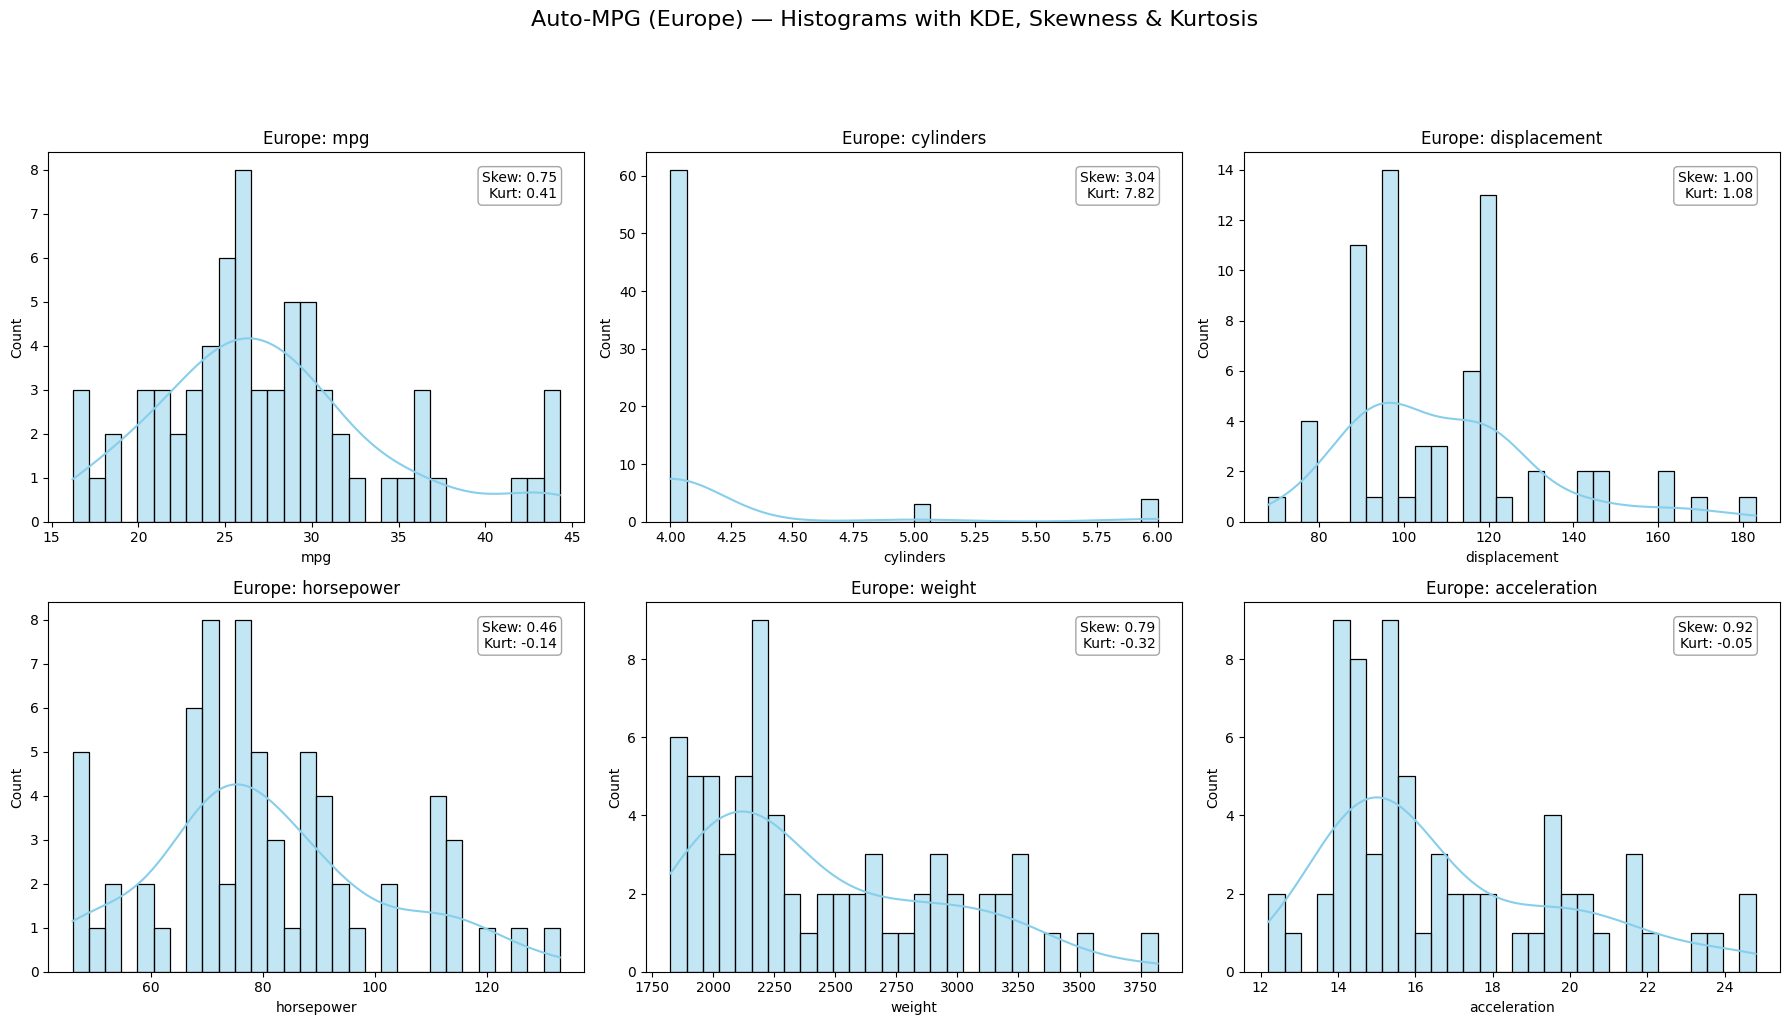

In [8]:
# Variables to plot
vars_to_plot = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]

# Loop through each origin
for origin in df["origin_label"].unique():
    subset = df[df["origin_label"] == origin]

    # Create 2x3 subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, var in enumerate(vars_to_plot):
        sns.histplot(
            data=subset,
            x=var,
            kde=True,
            color="skyblue",
            bins=30,
            ax=axes[i]
        )
        # Calculate skewness and kurtosis
        skew_val = skew(subset[var], nan_policy='omit')
        kurt_val = kurtosis(subset[var], nan_policy='omit')

        # Annotate on plot
        axes[i].text(
            0.95, 0.95,
            f"Skew: {skew_val:.2f}\nKurt: {kurt_val:.2f}",
            transform=axes[i].transAxes,
            ha="right", va="top",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )
        axes[i].set_title(f"{origin}: {var}")

    fig.suptitle(f"Auto-MPG ({origin}) — Histograms with KDE, Skewness & Kurtosis", fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#### 4.1 Visualization analysis

**Japanese**: mpg and horsepower show positive skew — most cars are efficient and modestly powered, with fewer low-mpg or high-horsepower outliers. Cylinders, displacement, weight, and acceleration are fairly symmetric, reflecting consistent design choices. Low kurtosis across most variables suggests broad, balanced distributions rather than extreme clustering. Japan’s automotive design emphasized consistency, efficiency, and moderate performance, with fewer extremes compared to USA cars.


**USA**: Cylinders and displacement show strong skew toward larger engines, reflecting the prevalence of big, multi-cylinder vehicles. mpg, horsepower, weight, and acceleration are more evenly distributed but lean toward lower efficiency and heavier builds compared to Japan/Europe. High kurtosis in cylinders highlights the dominance of specific engine types (especially 8-cylinder cars). USA’s automotive design emphasized large, powerful engines, resulting in heavier cars with lower mpg and slower acceleration compared to Japanese and European counterparts.

**European**: Cylinders and displacement are strongly skewed toward smaller, compact engines, reflecting Europe’s focus on efficiency. mpg distribution shows clustering around higher efficiency values compared to USA.Horsepower, weight, and acceleration are moderately skewed, reflecting balanced designs without extremes.
High kurtosis in cylinders highlights the dominance of 4-cylinder cars in Europe. Europe’s automotive design emphasized compact, efficient cars with moderate horsepower and lighter weights, achieving a balance between performance and fuel economy.

#### 5. Regplot with correlated variable:

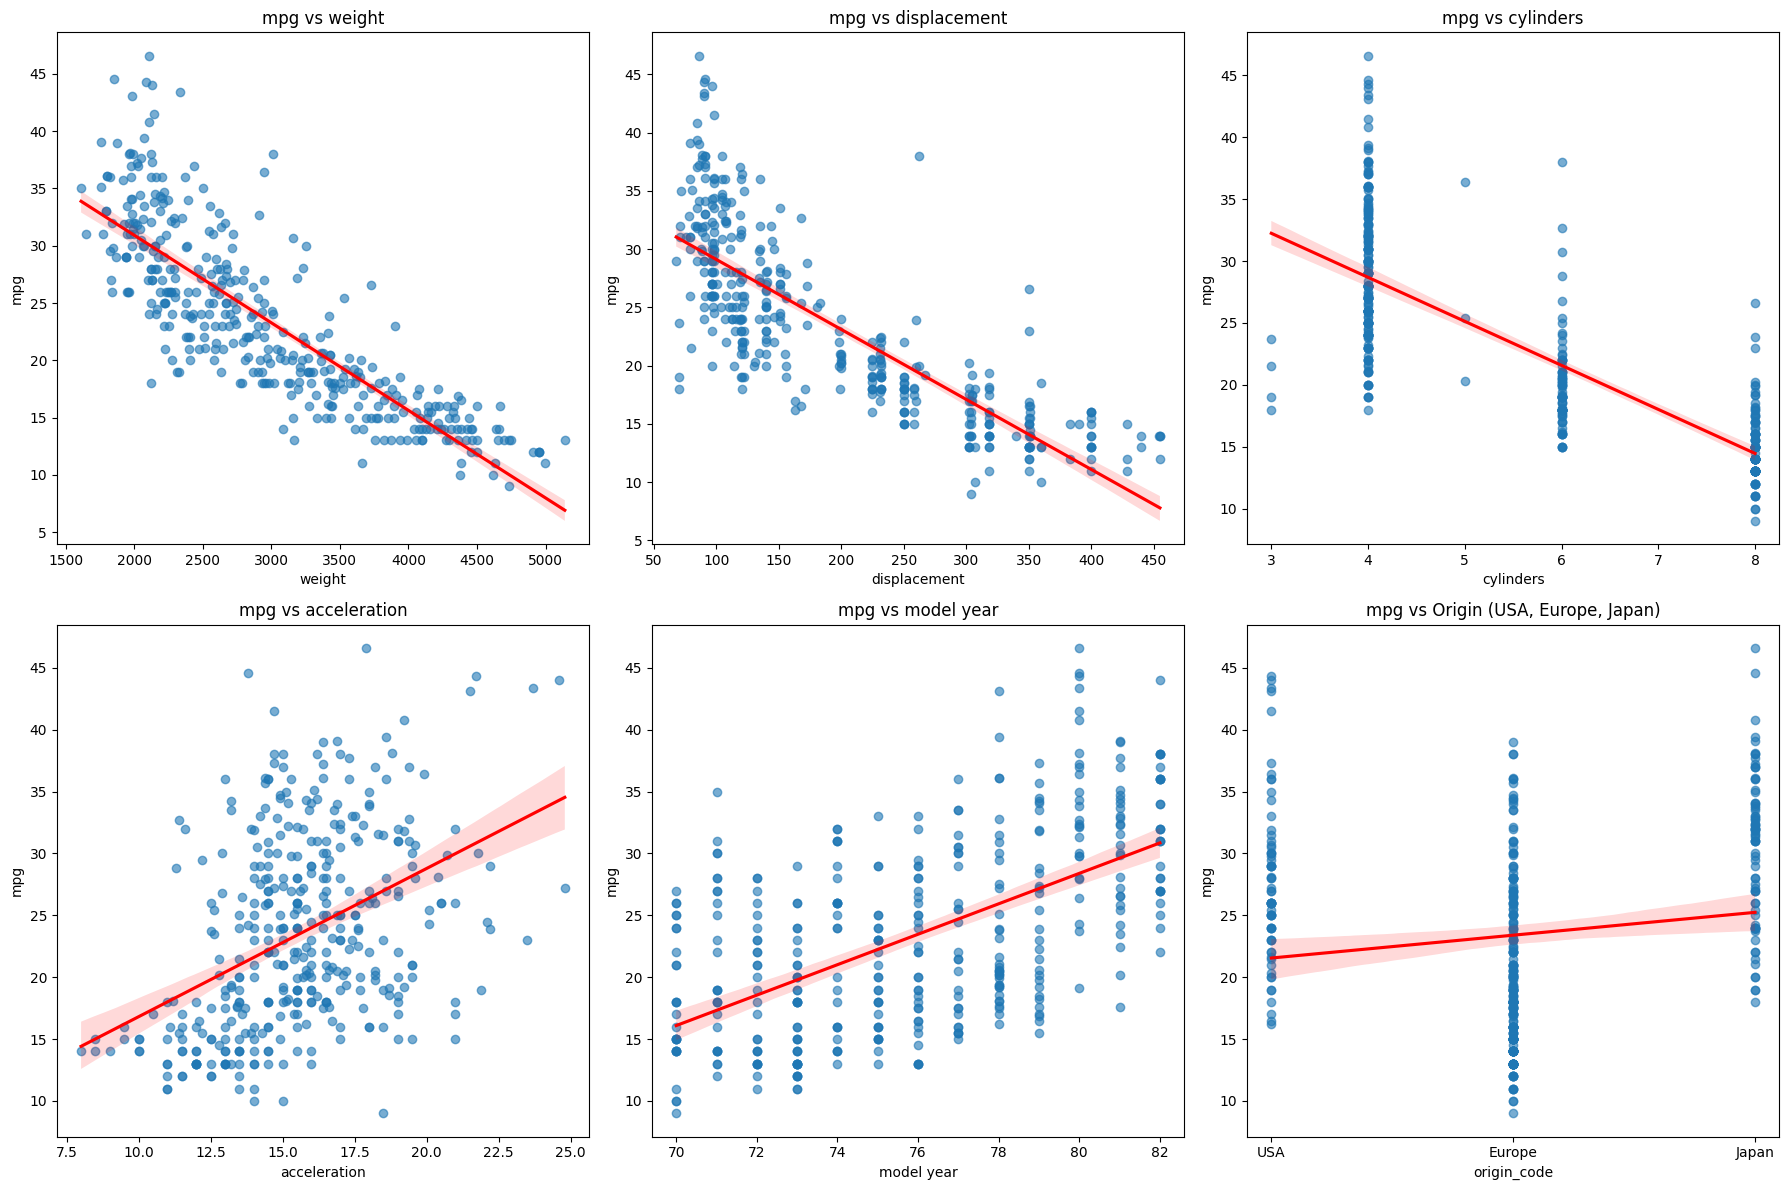

In [9]:
# Strongest correlations with mpg
strong_pairs = [
    ("mpg", "weight"),
    ("mpg", "displacement"),
    ("mpg", "cylinders"),
    ("mpg", "acceleration"),
    ("mpg", "model year"),
    ("mpg", "origin_code")  # numeric encoding for regplot
]

# Create 3x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (x, y) in enumerate(strong_pairs):
    sns.regplot(data=df, x=y, y=x, ax=axes[i],
                scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    
    # Special handling for origin_code axis labels
    if y == "origin_code":
        axes[i].set_xticks([0, 1, 2])
        axes[i].set_xticklabels(["USA", "Europe", "Japan"])
        axes[i].set_title(f"{x} vs Origin (USA, Europe, Japan)")
    else:
        axes[i].set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

#### 5.1 Regplot visualizations analysis

#### Top Row: Strong Negative Correlations:

##### mpg vs weight:

Strong negative correlation. *Heavier cars consume more fuel*. As weight increases, mpg drops sharply. Weight is one of the most influential predictors of fuel efficiency.

##### mpg vs displacement:

Strong negative correlation. *Larger engines (higher displacement)* tend to be *less fuel-efficient*. Engine size is closely tied to mpg — downsizing engines improves efficiency

##### mpg vs cylinders:

Moderate to strong negative correlation. *More cylinders usually mean more power and lower mpg*. Cylinders are technically categorical, but treated numerically here for regression.

#### Bottom Row: Positive Trends and Categorical Insight

#### mpg vs acceleration:

Weak to moderate positive correlation. C*ars with quicker acceleration tend to be more efficient* — possibly reflecting newer, lighter designs. This *relationship is weaker than weight or displacemen*t.

##### mpg vs model year:

Moderate positive correlation.* Newer cars have better fuel efficiency*. Technological improvements over time (e.g., emissions standards, engine design) led to higher mpg.

##### mpg vs origin (USA, Europe, Japan):

Slight negative slope across origin codes. Cars from Japan tend to have the highest mpg, followed by Europe, then USA. Origin is categorical, but encoded numerically for regression. Labels are correctly shown on the x-axis.

#### Reasons Japanese Cars Had Higher MPG:

##### Smaller, Lighter Designs:

Japanese manufacturers (Toyota, Honda, Datsun/Nissan, Mazda) focused on compact cars. Lower vehicle weight → less energy required to move → higher mpg.

##### Smaller Engines:

Cars from Japan typically had lower displacement engines (smaller cubic inches). Fewer cylinders and lower horsepower → reduced fuel consumption. Many Japanese cars had 4-cylinder engines, while American cars often had 6–8 cylinders.

##### Fuel Efficiency Focus

Japan faced higher fuel prices and stricter domestic efficiency needs


##### Global Market Strategy:

*After the 1973 oil crisis*, demand for fuel-efficient cars surged worldwide. Japanese automakers capitalized by exporting small, efficient cars to the US and Europe, reinforcing their reputation for high mpg.

- USA cars: heavier, larger engines → lower mpg.
- Europe cars: mid-range efficiency, often smaller than US but not as optimized as Japan.
- Japan cars: highest mpg due to design priorities.



#### 6. Cylinder configurations changed over the years by origin (USA, Europe, Japan):

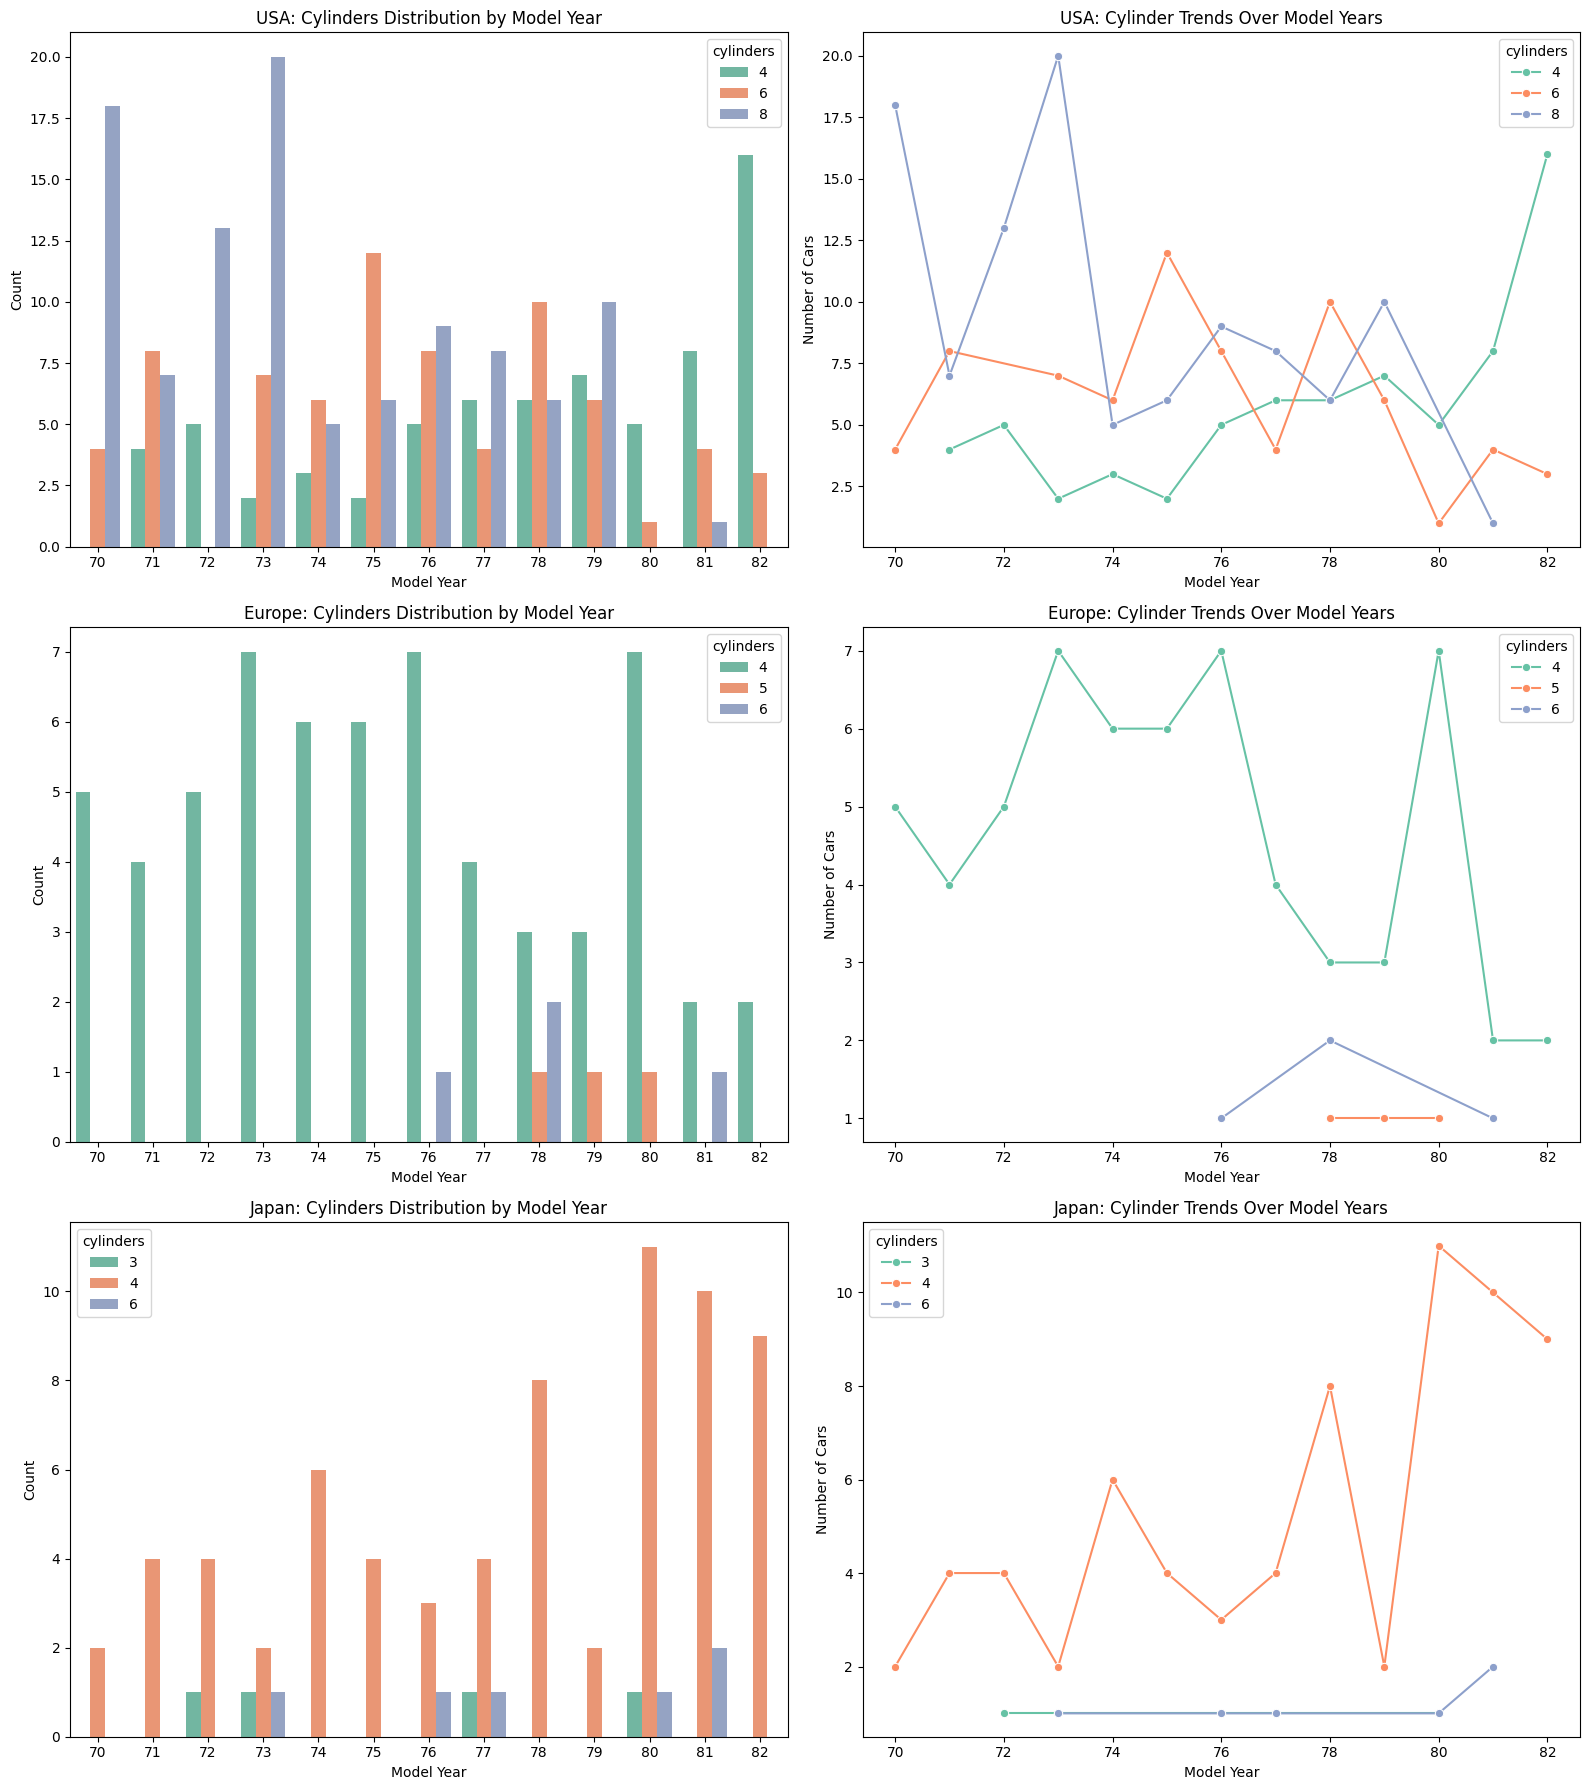

In [10]:
# Map origin codes to labels
df["origin"] = df["origin"].map({1: "USA", 2: "Europe", 3: "Japan"})

# Prepare aggregated data for lineplot
cyl_trend = df.groupby(["origin", "model year", "cylinders"]).size().reset_index(name="count")

# Create 3x2 subplot grid
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
origins = ["USA", "Europe", "Japan"]

for i, origin in enumerate(origins):
    # Left column: countplot
    sns.countplot(
        data=df[df["origin"] == origin],
        x="model year",
        hue="cylinders",
        palette="Set2",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{origin}: Cylinders Distribution by Model Year")
    axes[i, 0].set_xlabel("Model Year")
    axes[i, 0].set_ylabel("Count")

    # Right column: lineplot (trend of cylinder counts over years)
    sns.lineplot(
        data=cyl_trend[cyl_trend["origin"] == origin],
        x="model year",
        y="count",
        hue="cylinders",
        marker="o",
        ax=axes[i, 1],
        palette="Set2"
    )
    axes[i, 1].set_title(f"{origin}: Cylinder Trends Over Model Years")
    axes[i, 1].set_xlabel("Model Year")
    axes[i, 1].set_ylabel("Number of Cars")

plt.tight_layout()
plt.show()

#### 6.1 Cylinder configurations result analysis

#### USA
Early 1970s: Cars were dominated by 8-cylinder engines, reflecting the preference for large, powerful vehicles.
Mid to late 1970s, A noticeable decline in 8-cylinder cars, with 6-cylinder and especially 4-cylinder cars increasing. By early 1980s, The majority of cars shifted toward 4-cylinder engines, showing a strong move toward fuel efficiency after oil crises and regulatory changes.

#### Europe
Throughout the 1970s–1980s, Europe consistently favored smaller engines. 4-cylinder cars were dominant across all years. 5-cylinder and 6-cylinder cars appeared but remained relatively minor compared to the strong prevalence of 4-cylinder vehicles. Europe maintained a steady focus on efficiency and compact design

#### Japan
Early 1970s Mix of 3-cylinder and 4-cylinder cars, with 4-cylinder already strong. Late 1970s–1980s 4-cylinder cars became overwhelmingly dominant, while 3-cylinder and 6-cylinder cars declined. Japan rapidly standardized around 4-cylinder engines, aligning with its reputation for small, efficient vehicles.

Across all regions, the global automotive industry moved toward smaller, more efficient engines (4-cylinder) over time, driven by fuel economy concerns, regulations, and technological progress.

#### 7. Plot Miles per gallon vs variables i.e. cylinders, displacement, horsepower, weight, acceleration:

To see the visual effect how the miles per gallon affected by the variables. Plot categorized according origin.


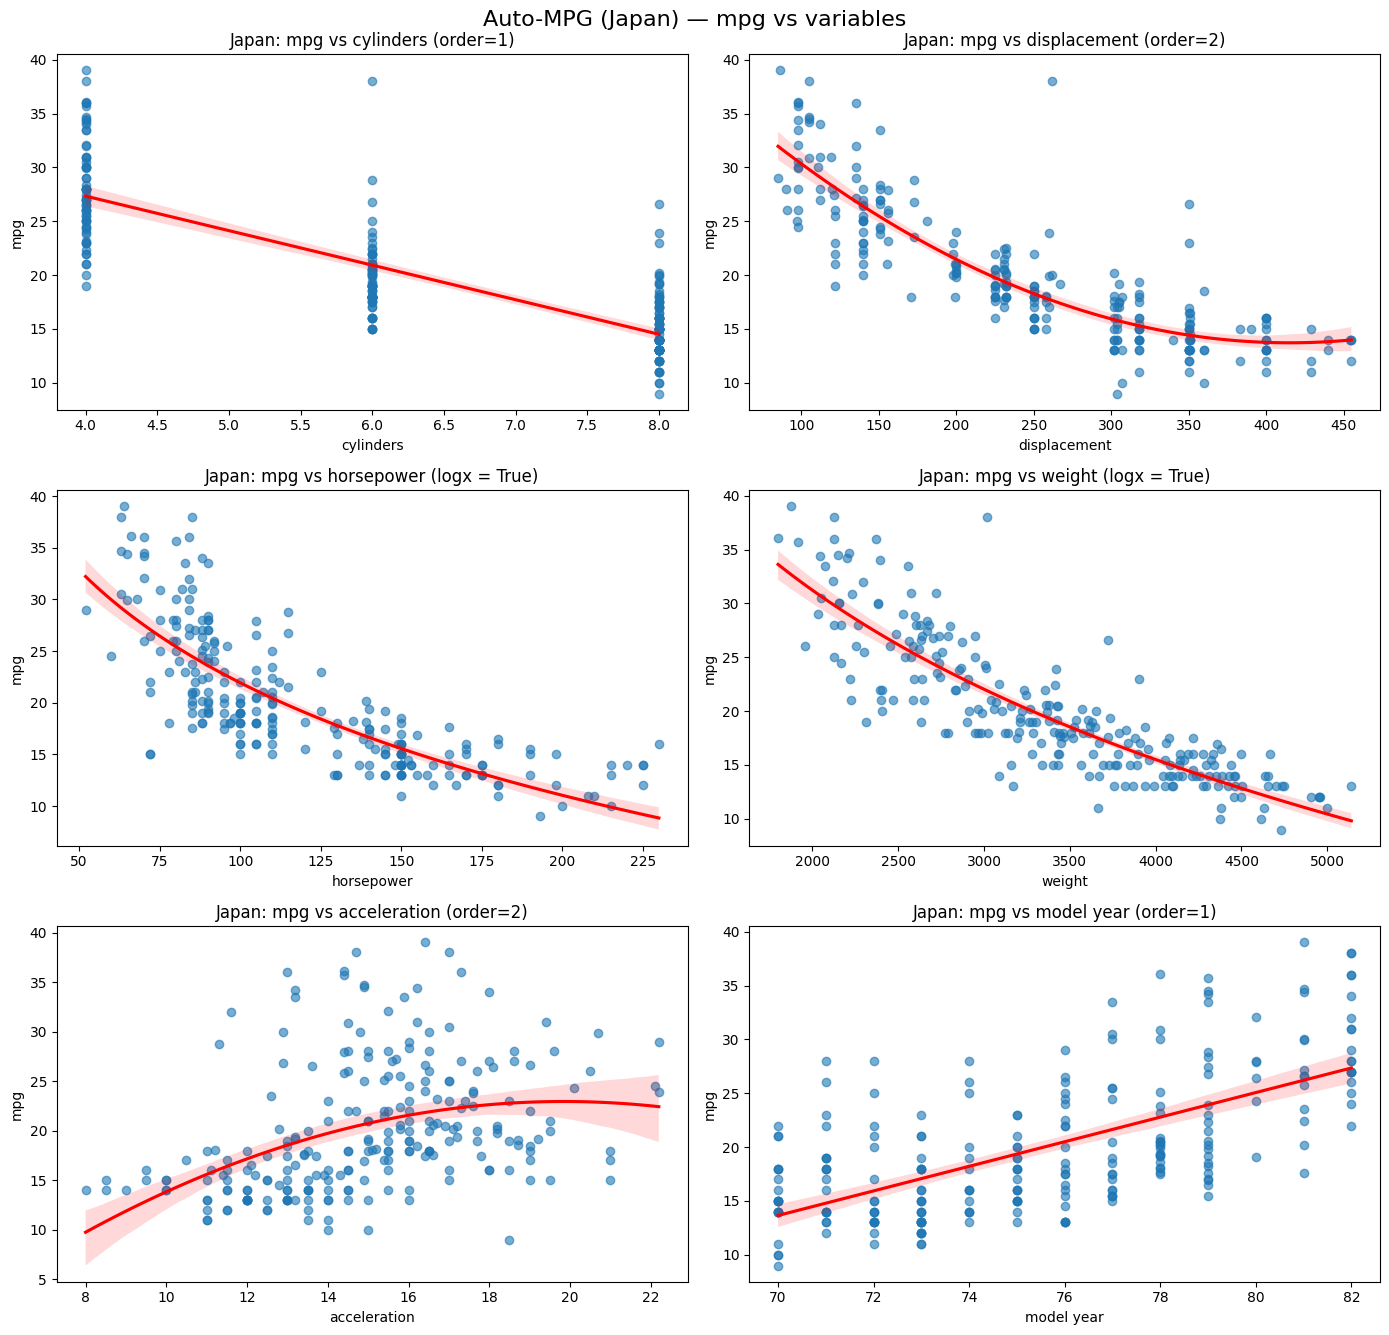

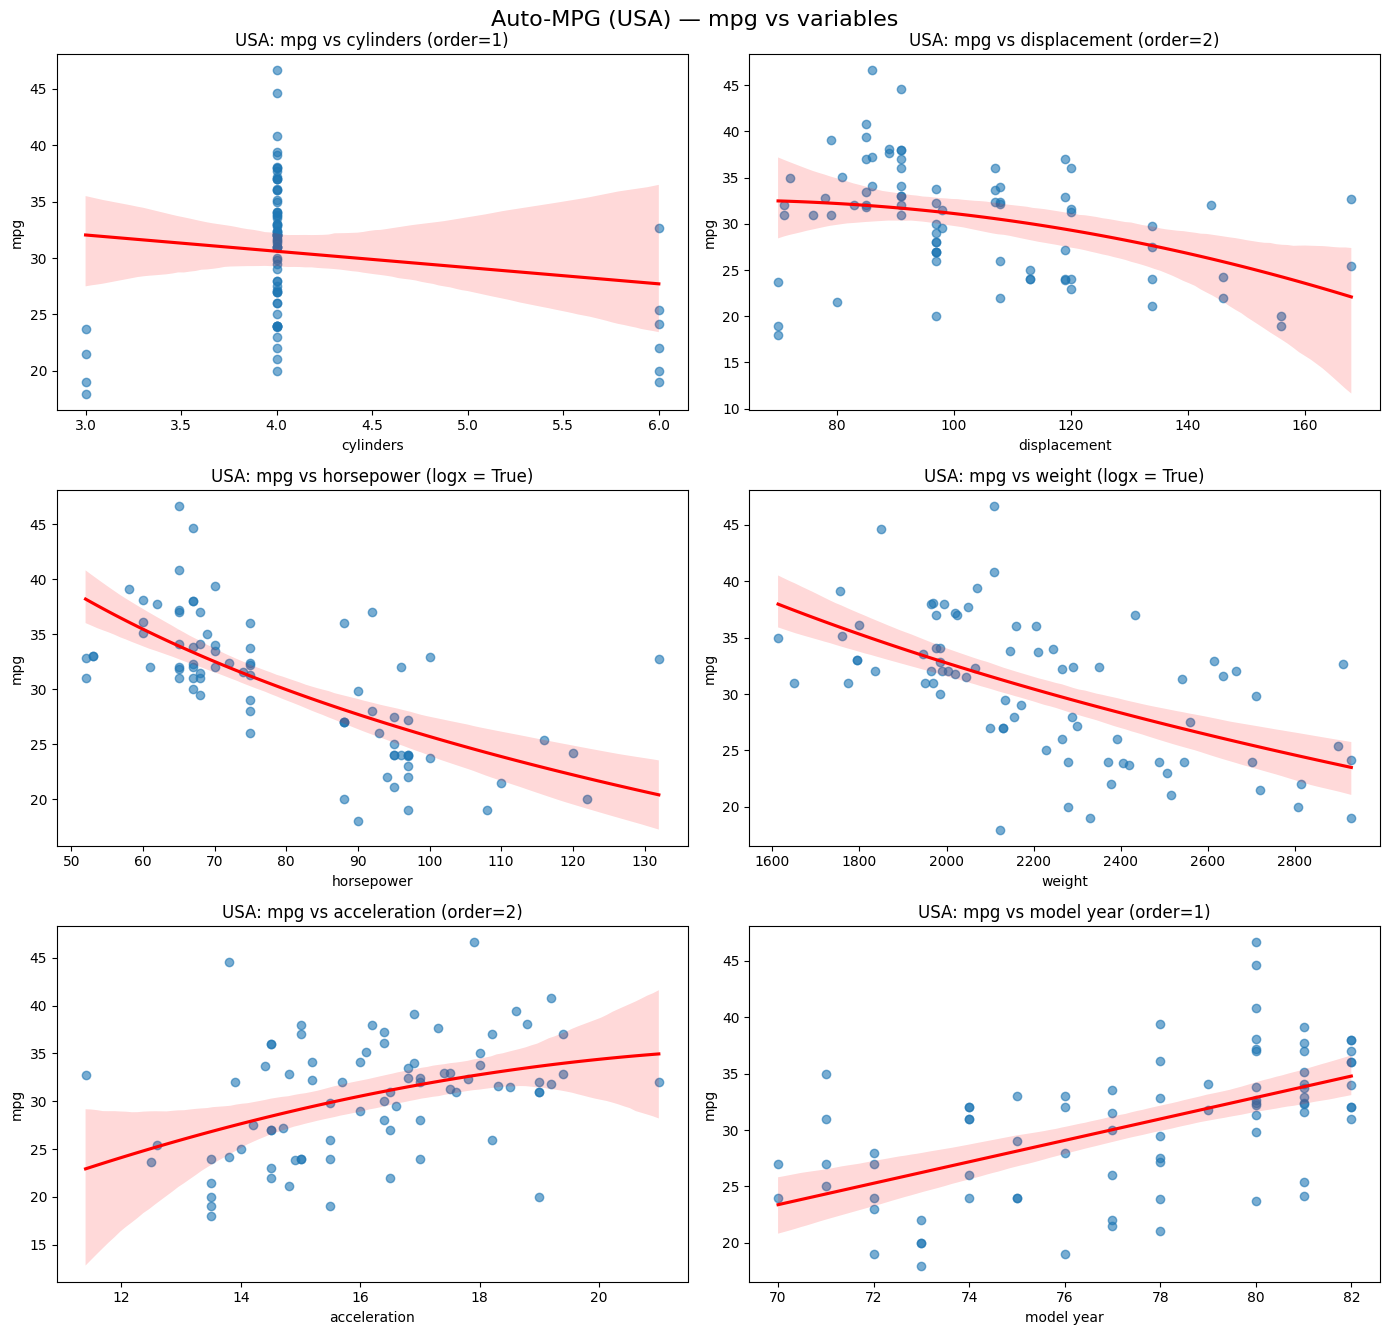

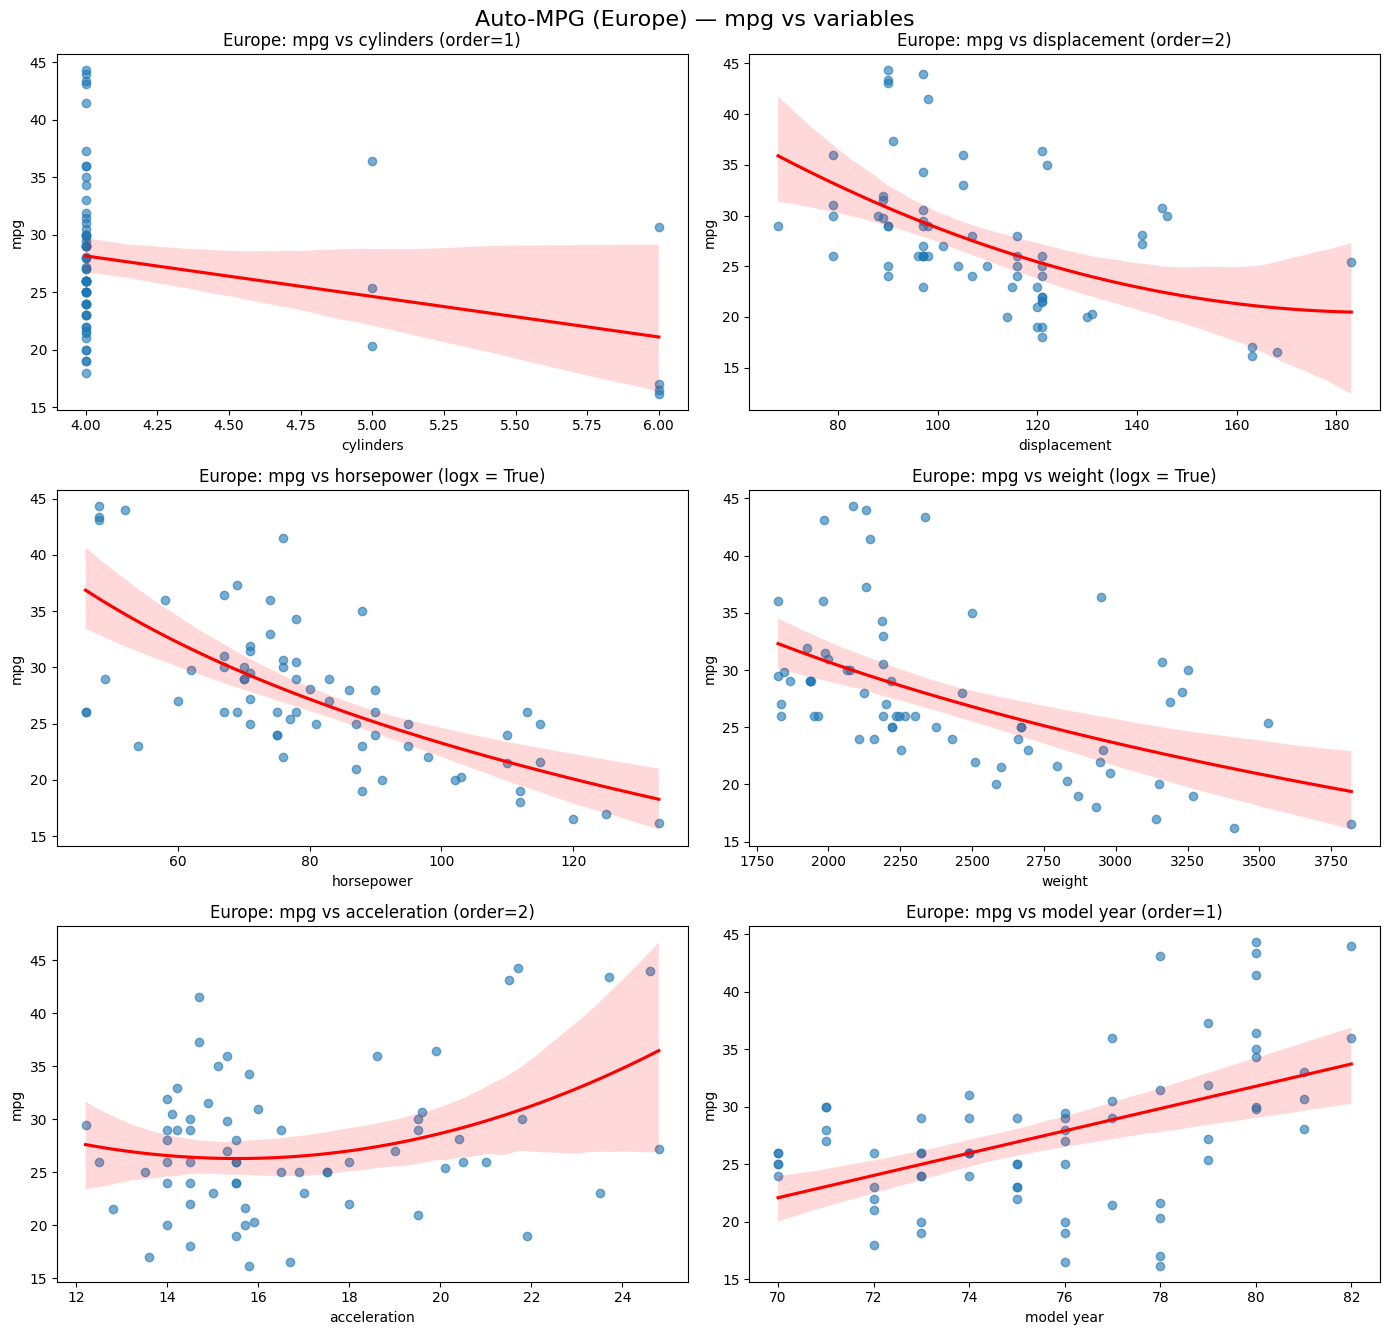

In [11]:
# Variables for plotting
y_vars = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model year"]

# Loop through each origin
for origin in df["origin_label"].unique():
    subset = df[df["origin_label"] == origin]

    # Create 3x2 subplot grid
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    axes = axes.flatten()

    for i, y_var in enumerate(y_vars):
        # Choose regression order
        if y_var in ["cylinders", "model year"]:
            order_val = 1
        else:
            order_val = 2
        if y_var in ["weight", "horsepower"]:
            sns.regplot(
                data=subset,
                x=y_var,
                y="mpg",            
                logx=True,
                scatter_kws={'alpha':0.6},
                line_kws={'color':'red'},
                ax=axes[i]
            )
        else:
            sns.regplot(
                data=subset,
                x=y_var,
                y="mpg",            
                order=order_val,
                scatter_kws={'alpha':0.6},
                line_kws={'color':'red'},
                ax=axes[i]
            )
        if y_var in ["weight", "horsepower"]:    
            axes[i].set_title(f"{origin}: mpg vs {y_var} (logx = True)")
        else:
            axes[i].set_title(f"{origin}: mpg vs {y_var} (order={order_val})")
    # Adjust layout
    fig.suptitle(f"Auto-MPG ({origin}) — mpg vs variables", fontsize=16, y = 0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

#### 7.1 Miles per gallon vs variables result analysis

#### MPG vs. variables across USA, Europe, and Japan:

***USA***: Cylinders, displacement, horsepower, weight: Strong negative impact on mpg. *Acceleration*, Mild positive nonlinear effect. *Model year*, Clear positive trend — efficiency improved over time. *USA* started with large, heavy, cylinder-rich cars, but gradually shifted toward smaller, more efficient designs due to regulations and oil crises.

***Europe***: Cylinders, displacement, horsepower, weight: Negative correlations, but less extreme than USA. *Acceleration*, Mild nonlinear relationship. *Model year*, Strong positive trend — newer cars consistently more efficient. Europe consistently favored smaller, lighter cars with fewer cylinders, maintaining better mpg than USA vehicles throughout.

***Japan***: Cylinders, displacement, horsepower, weight Strong negative impact on mpg, similar to Europe. **Acceleration** Nonlinear relationship, moderate effect. **Model year** Strong positive trend — efficiency improved steadily. Japan rapidly standardized around 4-cylinder, lighter cars, achieving consistently high mpg compared to USA and Europe.

- USA: Initially inefficient (large, heavy engines), but improved over time.
- Europe: Maintained efficiency by favoring smaller, lighter cars from the start.
- Japan: Led in efficiency, with strong focus on compact, fuel-efficient designs

Across all regions, mpg was most negatively tied to engine size (cylinders, displacement, horsepower) and weight, while model year showed consistent improvements. Japan and Europe were ahead in efficiency trends, while USA adapted later under external pressures.

#### 8. Distribution density plot of each variable by origin:

This visualization shows how automobile attributes evolved over time (1970–1982) across USA, Europe, and Japan, using violin plots to capture the distribution density of each variable by origin.

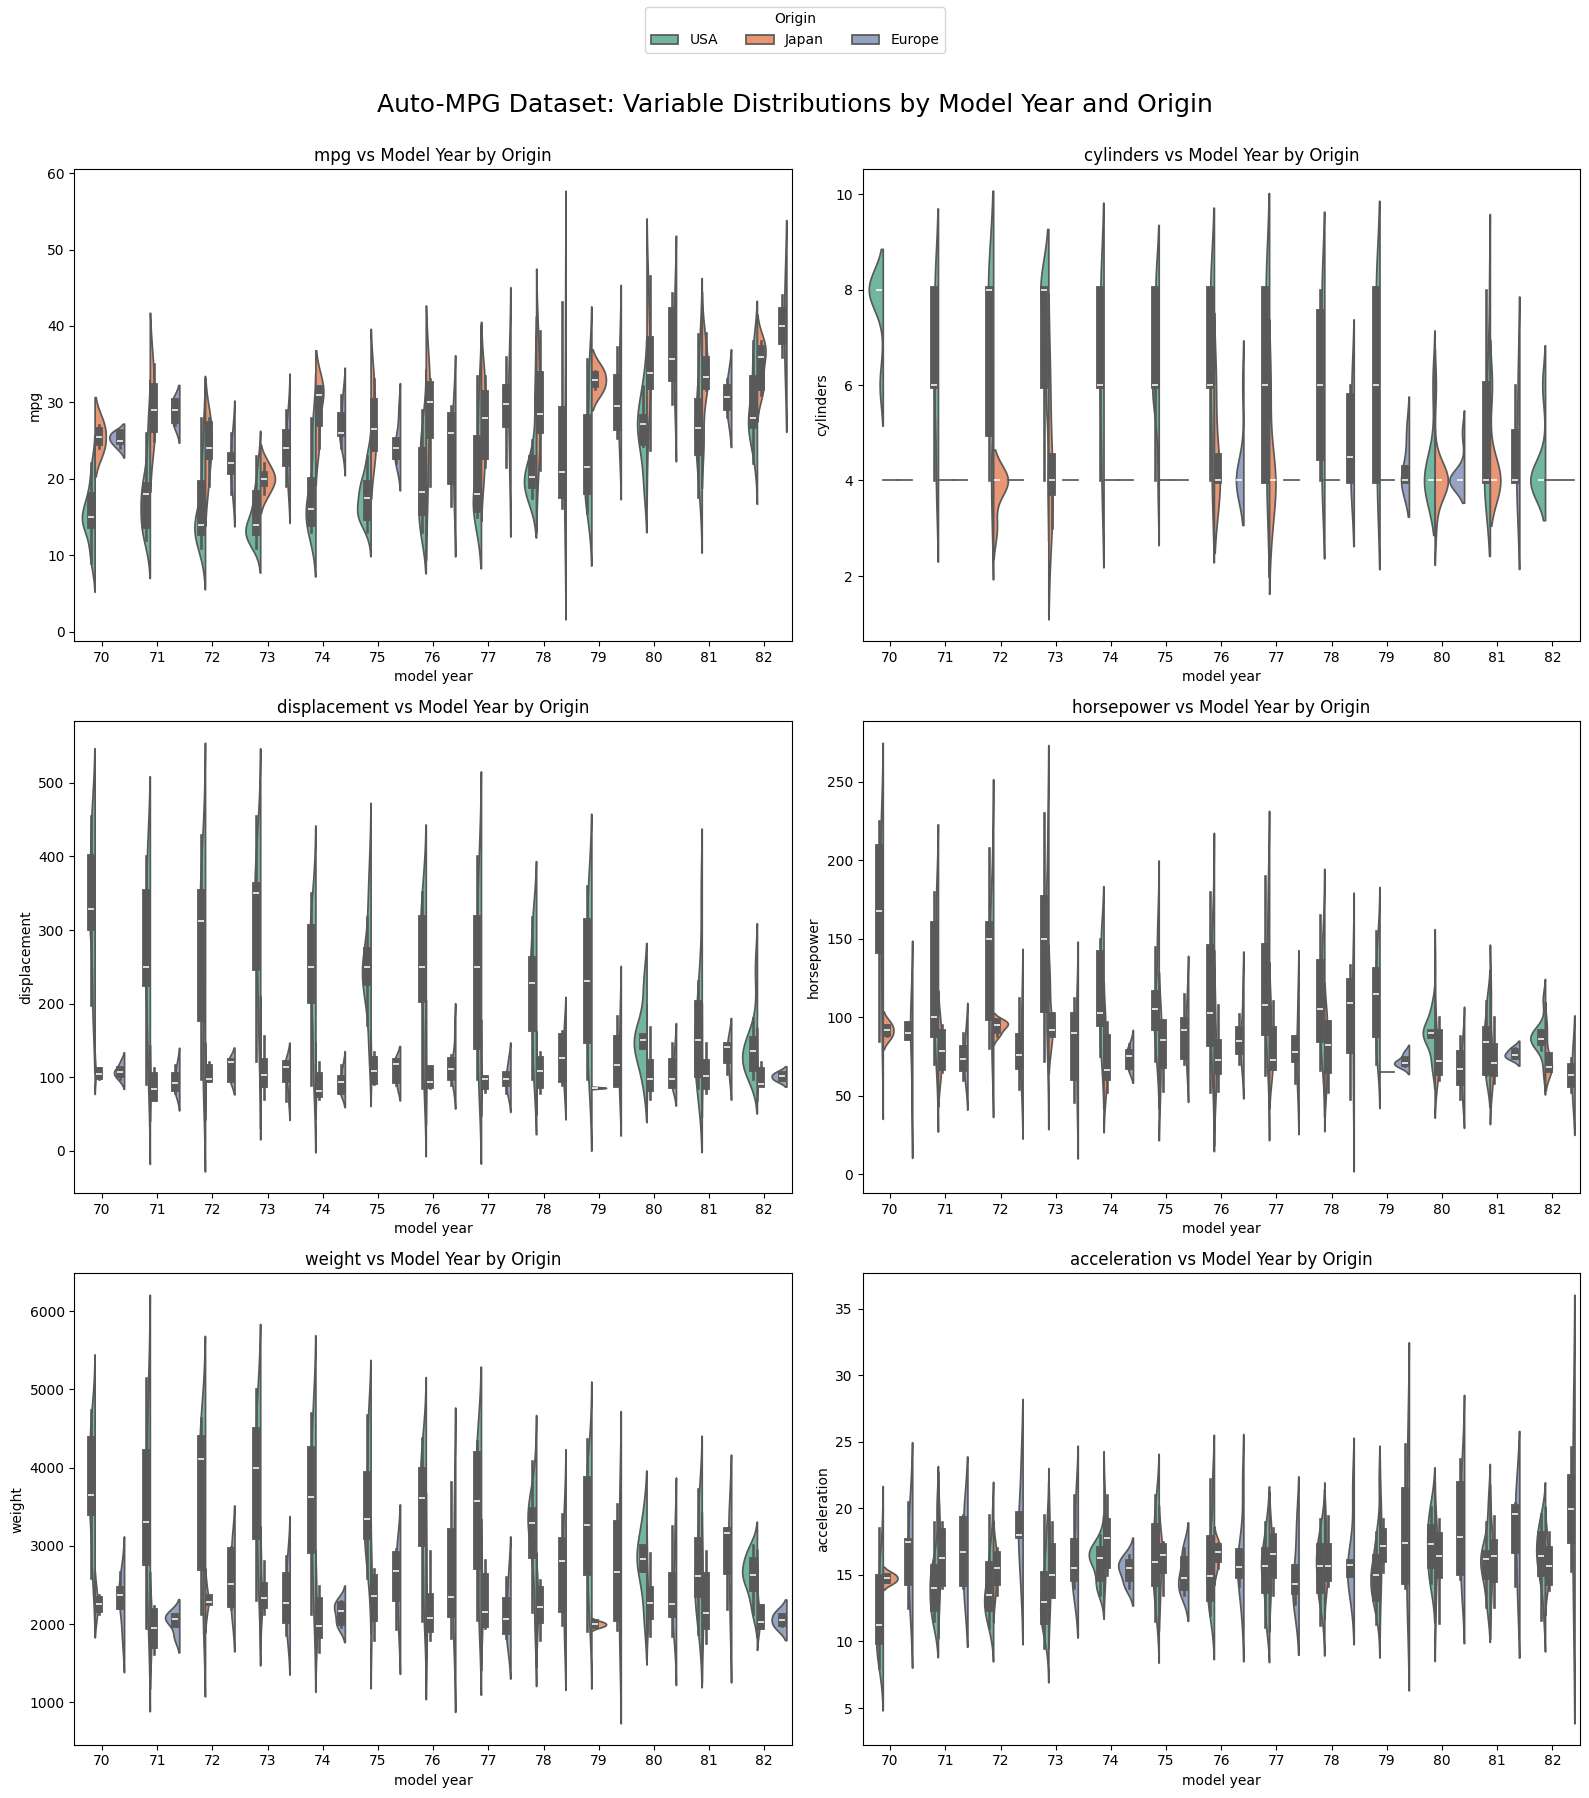

In [12]:
# Variables to plot
y_vars = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration"]

# Create 3x2 subplot grid
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# Loop through variables and plot violinplots
for i, y_var in enumerate(y_vars):
    sns.violinplot(
        data=df,
        x="model year",
        y=y_var,
        hue="origin",
        split=True,
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(f"{y_var} vs Model Year by Origin")
    axes[i].legend_.remove()  # remove duplicate legends

# Add one legend outside the grid
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Origin", loc="upper center", ncol=3)

fig.suptitle("Auto-MPG Dataset: Variable Distributions by Model Year and Origin", 
             fontsize=18, y=0.95)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### 8.1 Distribution density plot Result analysis

**USA** Started with large, heavy, high-cylinder cars with poor mpg, but shifted toward smaller, lighter, more efficient designs by the 1980s. USA Lower mpg in early years, gradually improving after mid-1970s. Shift from dominance of 8 cylinders in early 1970s to more 4-cylinder cars by 1980s. Very high displacement early on, declining over time. High horsepower in early years, decreasing after mid-1970s. Slower acceleration in early years, improving gradually.

**Europe & Japan** Led in efficiency, consistently producing lightweight, 4-cylinder cars with high mpg. Consistently higher mpg, with steady improvement over time. **Europe** Mostly 4–6 cylinders, stable trend, **Japan** Predominantly 4 cylinders, with occasional 3 or 6 cylinders. Lower displacement overall, with gradual reductions. Consistently lighter cars, with gradual reductions. Generally better acceleration, with steady improvements.

- USA: Started with large, heavy, high-cylinder cars with poor mpg, but shifted toward smaller, lighter, more efficient designs by the 1980s.
- Europe: Maintained a steady focus on smaller, efficient cars with moderate power.
- Japan: Led in efficiency, consistently producing lightweight, 4-cylinder cars with high mpg.

Across all regions, the 1970s–1980s marked a global transition toward fuel efficiency, smaller engines, and lighter vehicles, with Japan and Europe ahead of the USA in adopting these trends.


#### 9. Cylinder distribution comparison (USA vs Europe vs Japan)


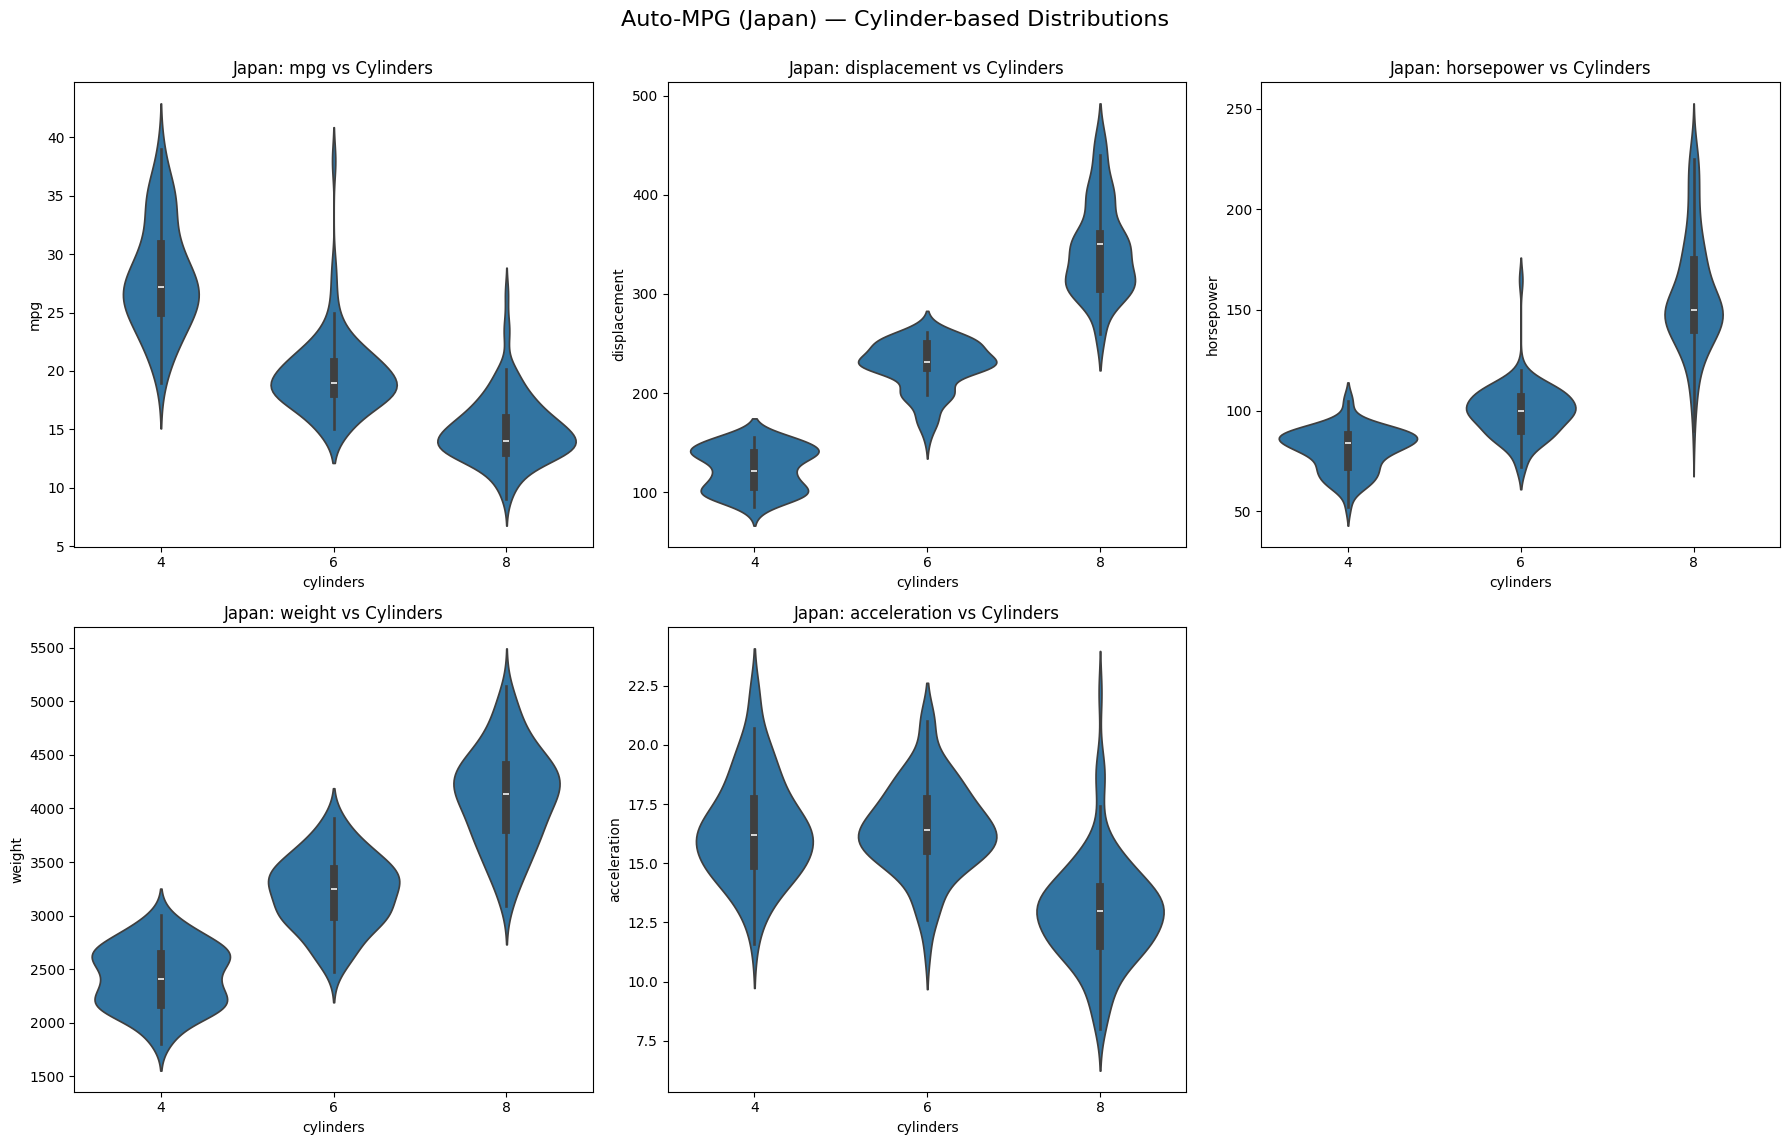

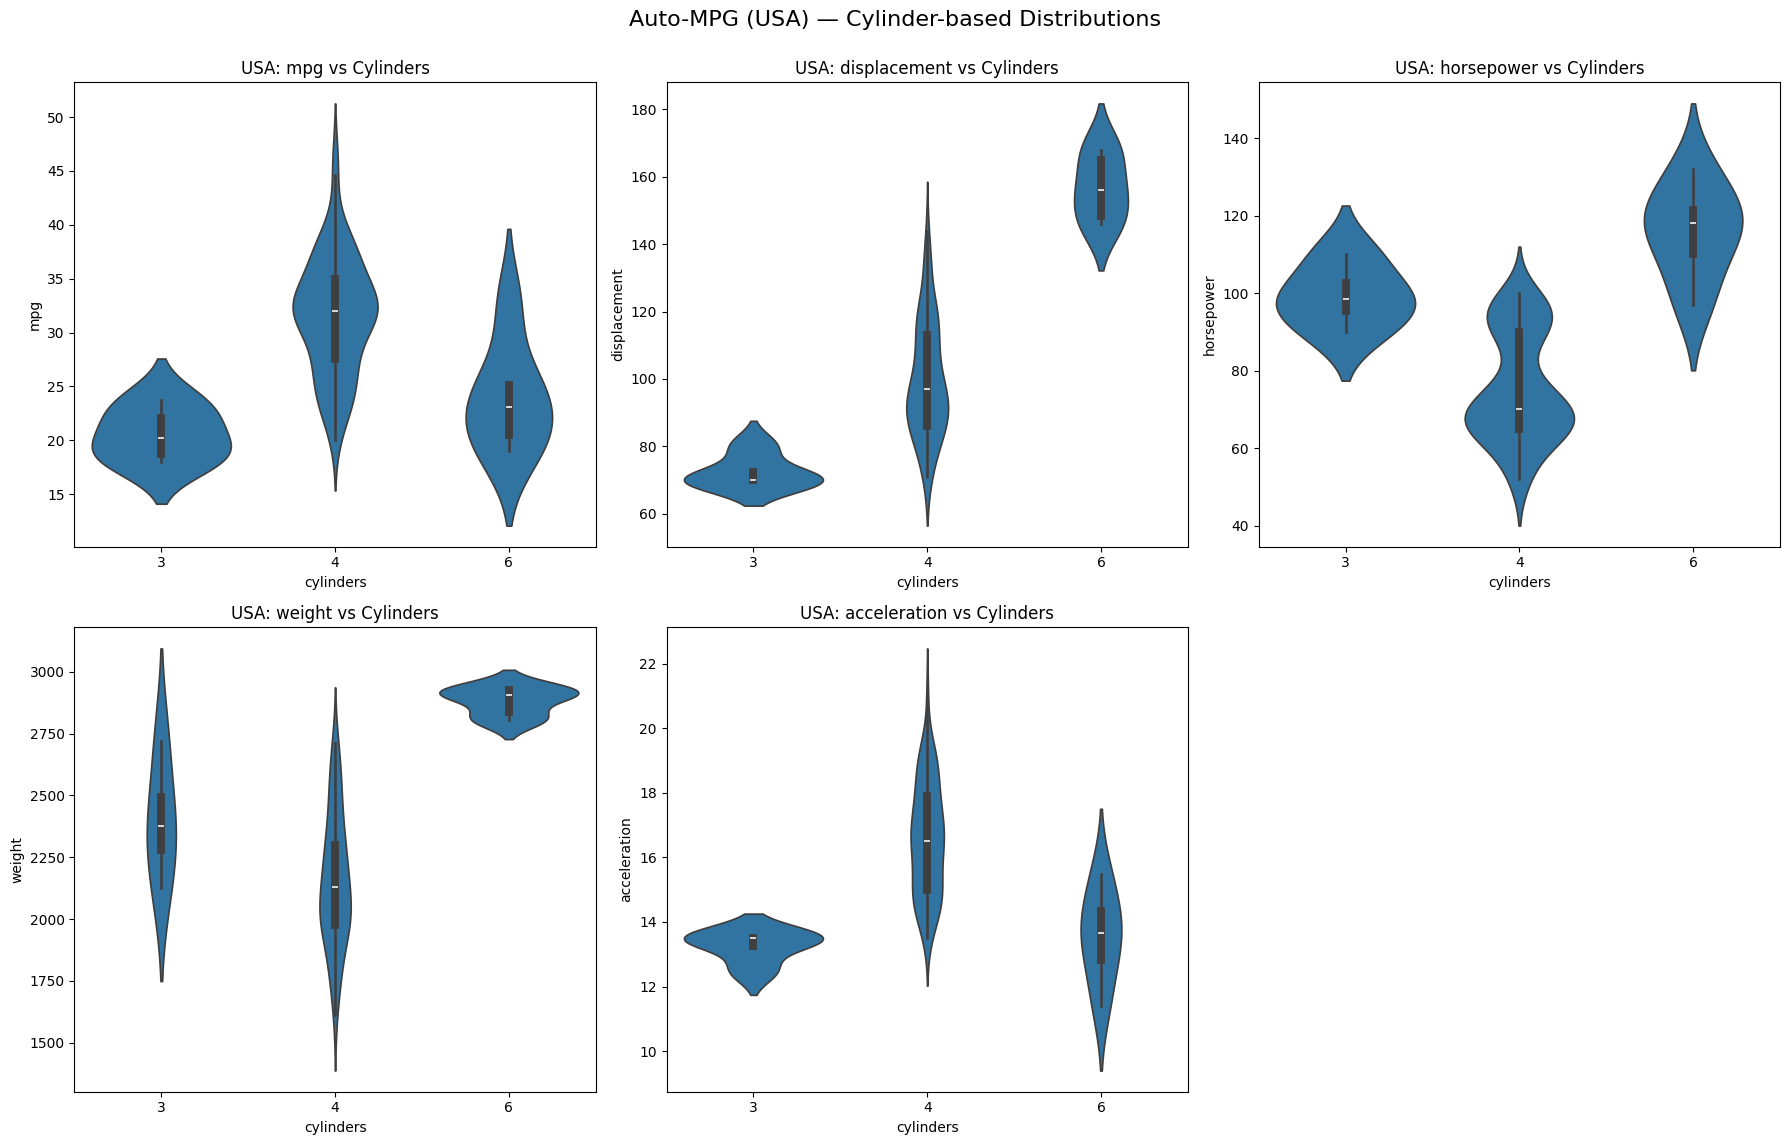

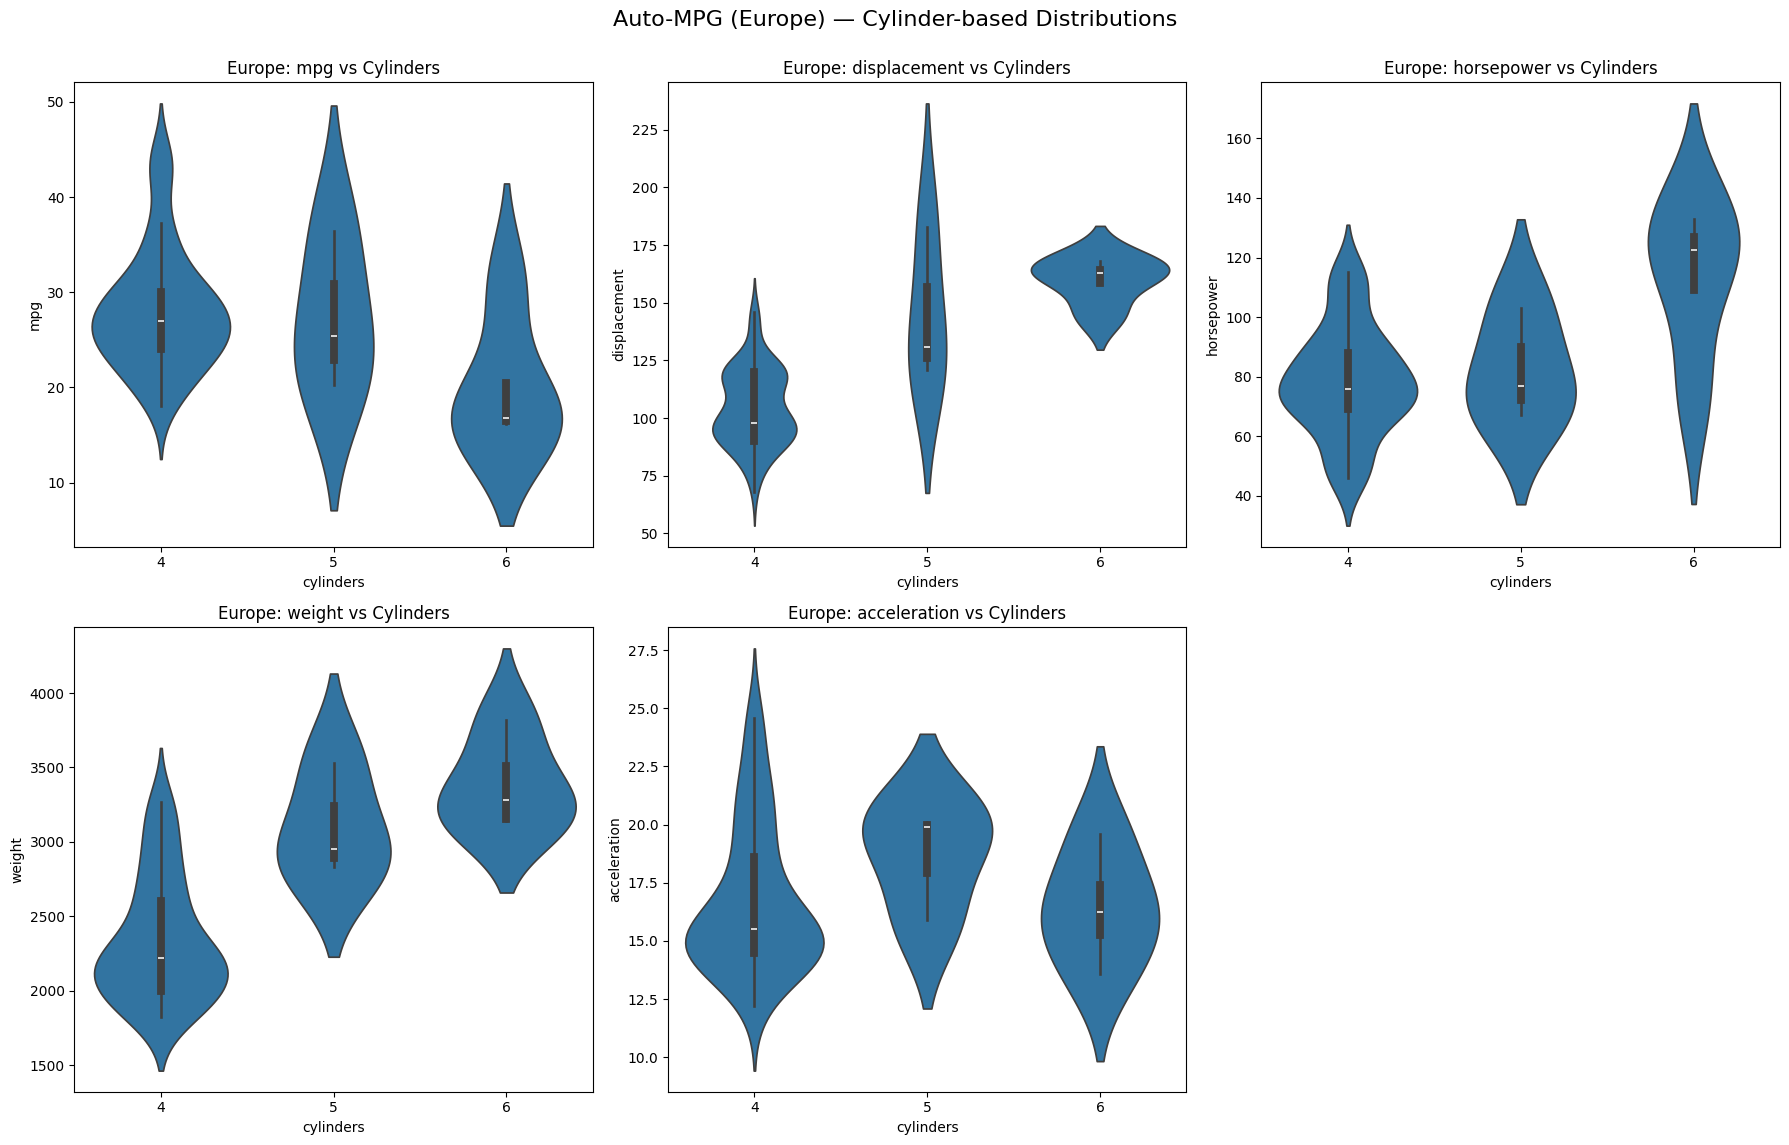

In [13]:
# Variables to plot
y_vars = ["mpg", "displacement", "horsepower", "weight", "acceleration"]

# Loop through each origin
for origin in df["origin_label"].unique():
    subset = df[df["origin_label"] == origin]

    # Create 2x3 subplot grid (total 6 slots)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, y_var in enumerate(y_vars):
        sns.violinplot(
        data=subset,
        x="cylinders",
        y=y_var,
        ax=axes[i]
        )

        axes[i].set_title(f"{origin}: {y_var} vs Cylinders")

    # Hide the unused subplot slot (to avoid blank plot)
    for j in range(len(y_vars), len(axes)):
        axes[j].axis("off")

    # Add subtitle for each origin
    fig.suptitle(f"Auto-MPG ({origin}) — Cylinder-based Distributions", fontsize=16, y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#### 9.1 Cylinder distribution comparison result analysis

**Cylinder Distribution Comparison (USA vs Europe vs Japan):**

**USA**: Early dominance of 6- and 8-cylinder cars, reflecting preference for large, powerful engines. Over time, a shift toward 4-cylinder cars as regulations and fuel crises pushed efficiency. Larger displacement, higher horsepower, and heavier weights strongly tied to cylinder count. Efficiency (mpg) improved later compared to Europe and Japan.

**Europe**: Predominantly 4-cylinder cars, with some 5- and 6-cylinder models. Engines remained smaller and lighter overall, maintaining better mpg. Cylinder count strongly linked to displacement and horsepower, but less extreme than USA. Consistent focus on compact, efficient designs throughout the 1970s–1980s

**Japan**: Almost exclusively 4-cylinder cars, with occasional 3- or 6-cylinder models. Strong emphasis on lightweight, small-displacement vehicles. High mpg maintained across cylinder categories, with better acceleration relative to heavier cars. Japan led in efficiency, setting the benchmark for compact, fuel-efficient vehicles

Across all regions, the global automotive industry converged toward 4-cylinder, lighter, more efficient cars by the 1980s. Japan was the most efficiency-focused, Europe maintained steady compact designs, while USA adapted later under external pressures.

#### 10. Visualization plot engine displacement relates to other vehicle characteristics:


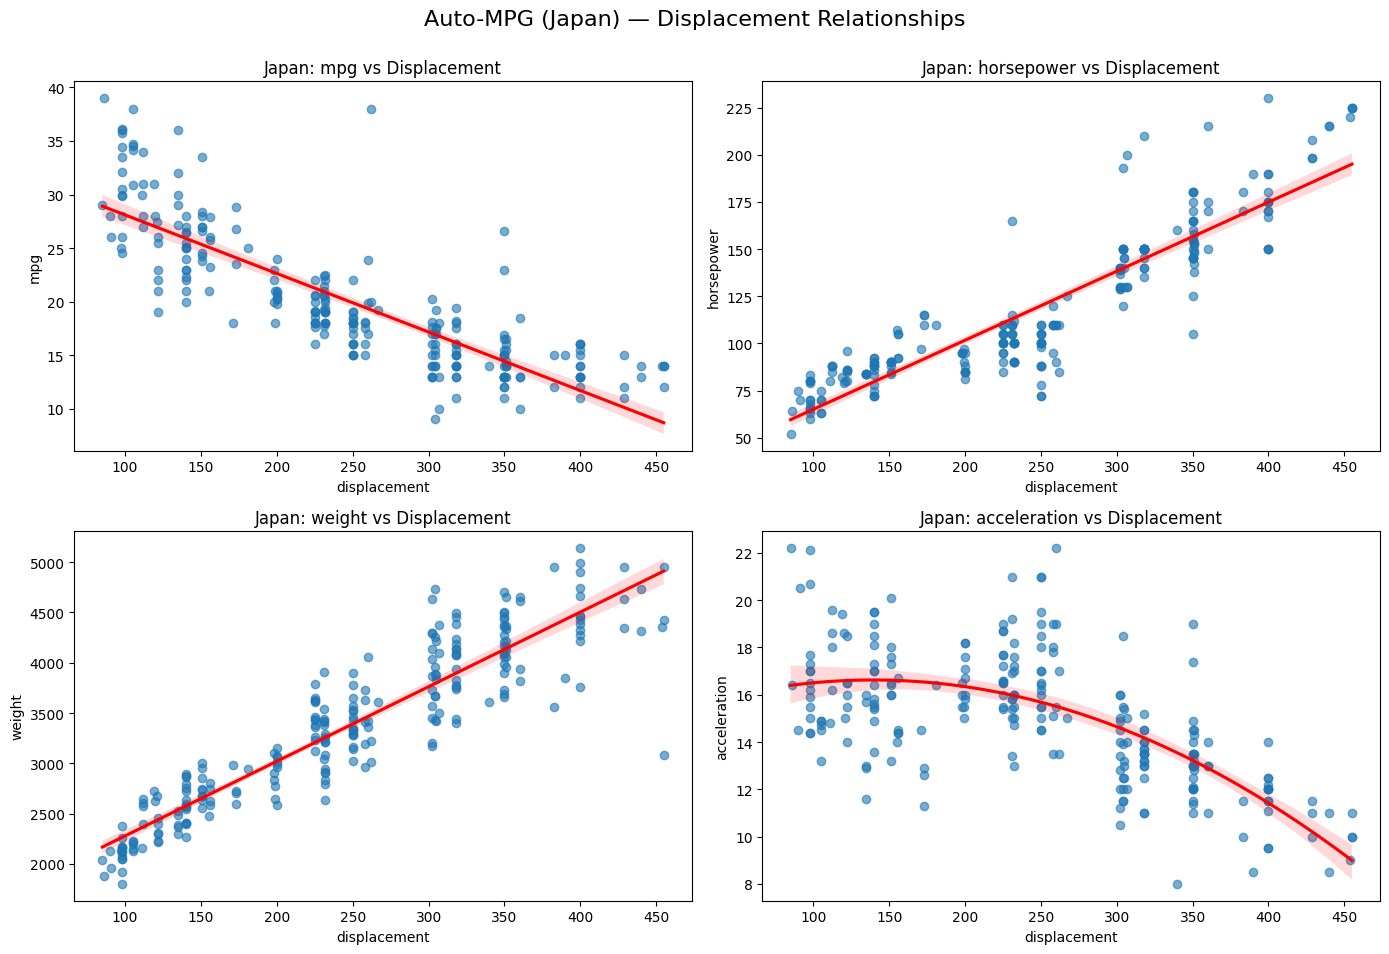

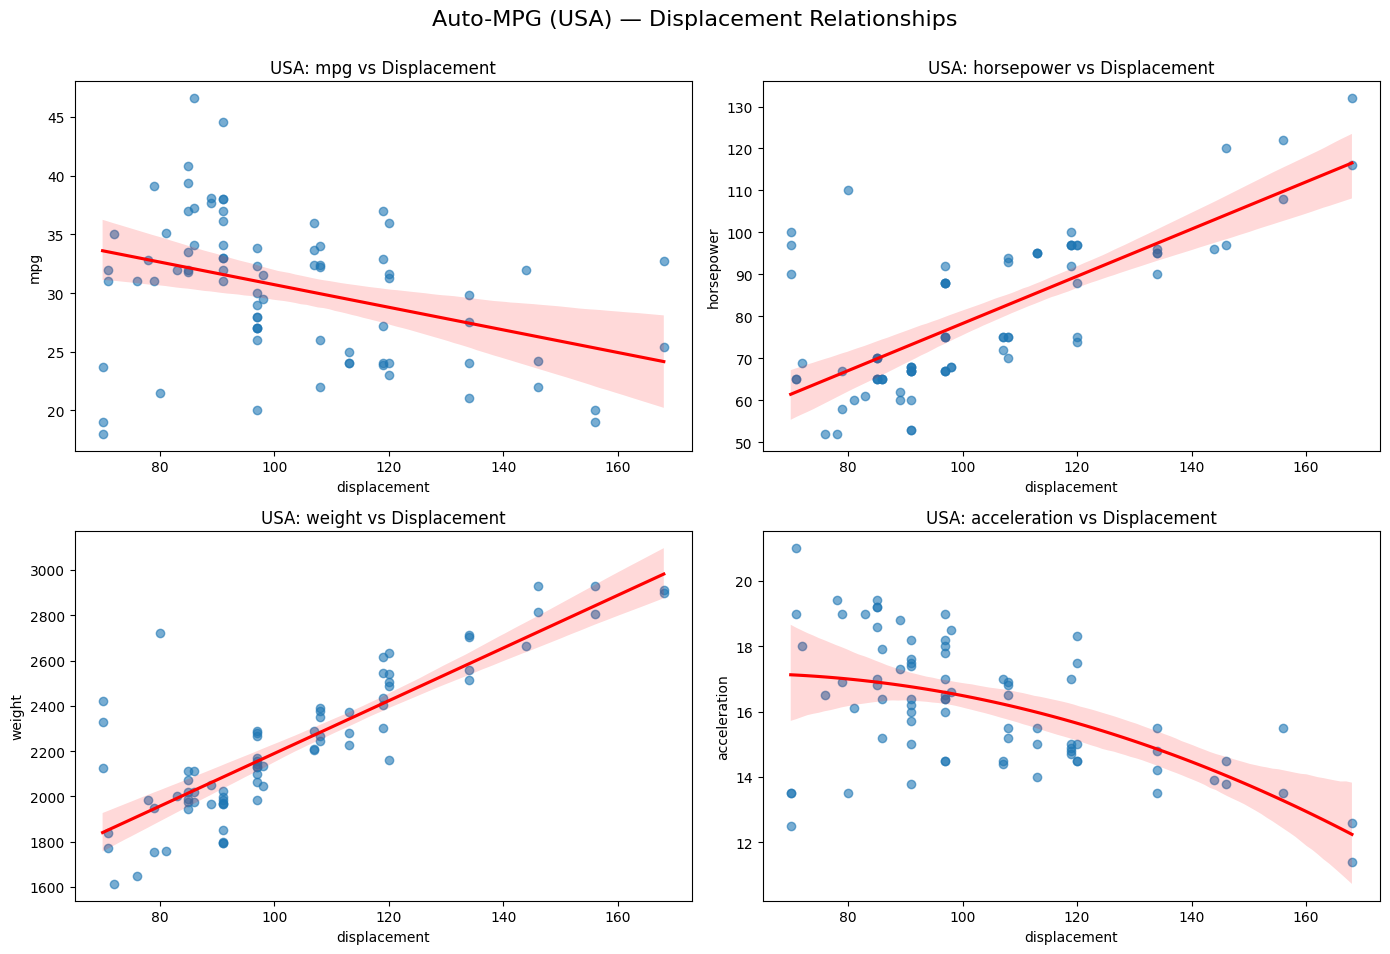

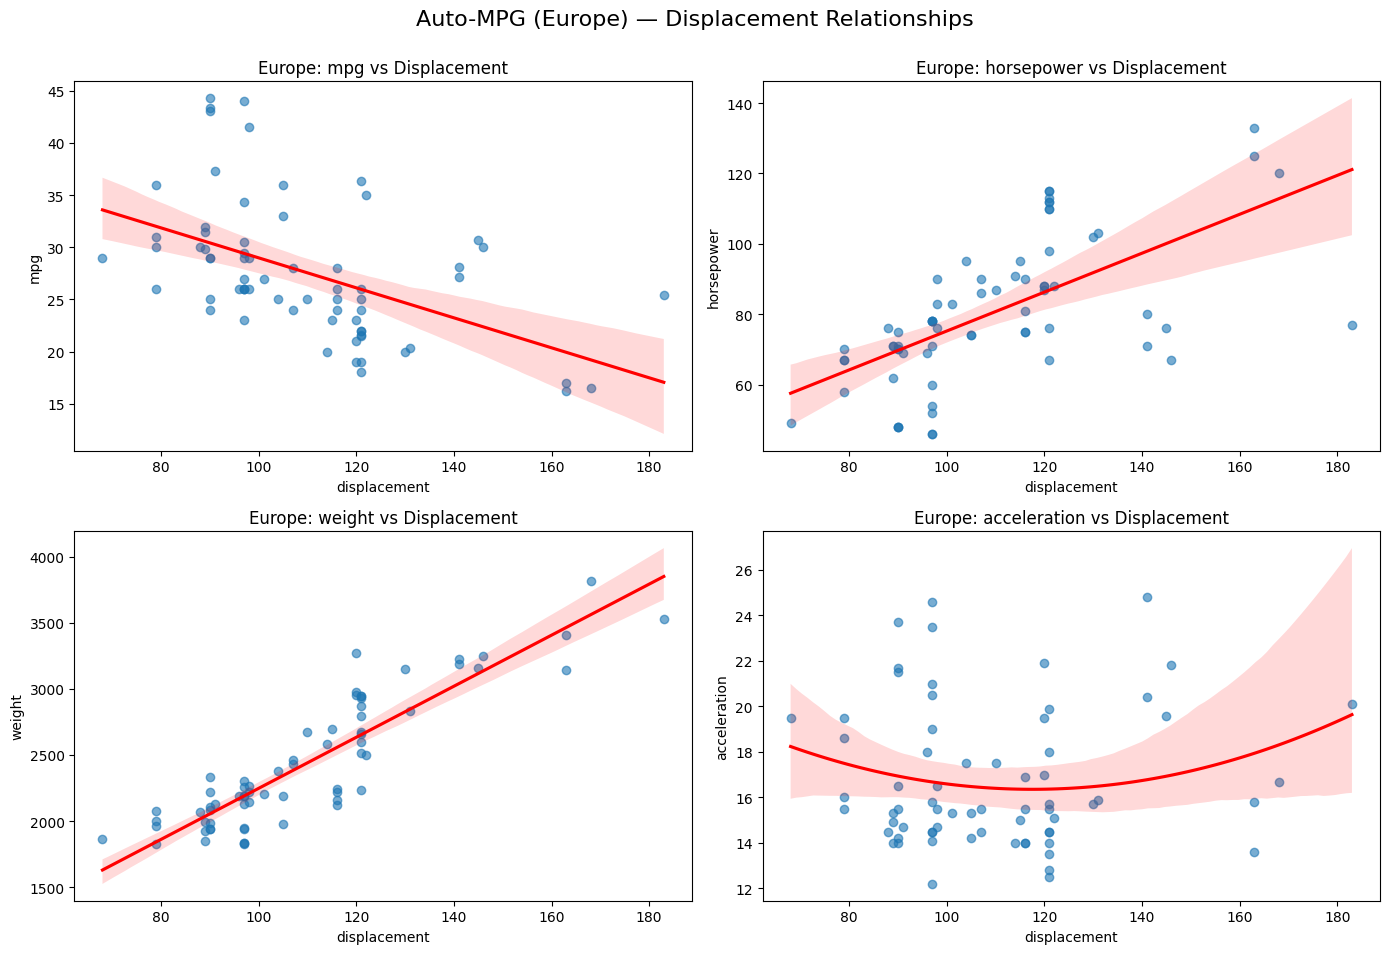

In [14]:
# Variables to plot
y_vars = ["mpg", "horsepower", "weight", "acceleration"]

# Loop through each origin
for origin in df["origin_label"].unique():
    subset = df[df["origin_label"] == origin]

    # Create 2x2 subplot grid for this origin
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, y_var in enumerate(y_vars):
        if y_var == 'acceleration':            
            sns.regplot(
            data=subset,
            x="displacement",
            y=y_var,
            scatter_kws={'alpha':0.6},
            line_kws={'color':'red'},
            order=2,
            ax=axes[i]
            )
        else:
            sns.regplot(
            data=subset,
            x="displacement",
            y=y_var,
            scatter_kws={'alpha':0.6},
            line_kws={'color':'red'},            
            ax=axes[i]
            )
        axes[i].set_title(f"{origin}: {y_var} vs Displacement")

    fig.suptitle(f"Auto-MPG ({origin}) — Displacement Relationships", fontsize=16, y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#### 10.1 Visualization plot engine displacement result analysis

#### Displacement Relationships:

Fuel Efficiency (mpg): Strong negative correlation — larger displacement engines consume more fuel, reducing mpg. Smaller displacement engines are consistently more efficient.

Horsepower: Clear positive correlation — bigger displacement engines produce more horsepower. This reflects the natural link between engine size and power output.

Weight: Strong positive correlation — cars with larger displacement engines are heavier. Heavier vehicles further reduce mpg and agility.

Acceleration: Generally negative or nonlinear relationship, higher displacement often reduces acceleration.
Smaller, lighter cars with lower displacement accelerate better.

Engine displacement acts as a **central driver of vehicle performance and efficiency**:
- Larger displacement → more power, heavier weight, lower mpg, slower acceleration.
- Smaller displacement → lighter cars, higher mpg, better acceleration, but modest horsepower.

**USA** emphasized large displacement for power but sacrificed efficiency. USA’s automotive design in this era emphasized large, powerful engines, but this came at the expense of fuel efficiency and performance balance.

**Europe** balanced moderate displacement with efficiency. Europe’s automotive design emphasized compact, moderate-power engines, achieving a balance between efficiency and performance without the extremes of USA’s large engines.

**Japan** focused on small displacement engines, achieving high mpg and agility. Japan’s automotive design favored small-displacement, lightweight engines, achieving high mpg and better acceleration compared to larger, heavier vehicles.

####  11. Visualization plot horsepower vs other vehicle characteristics:


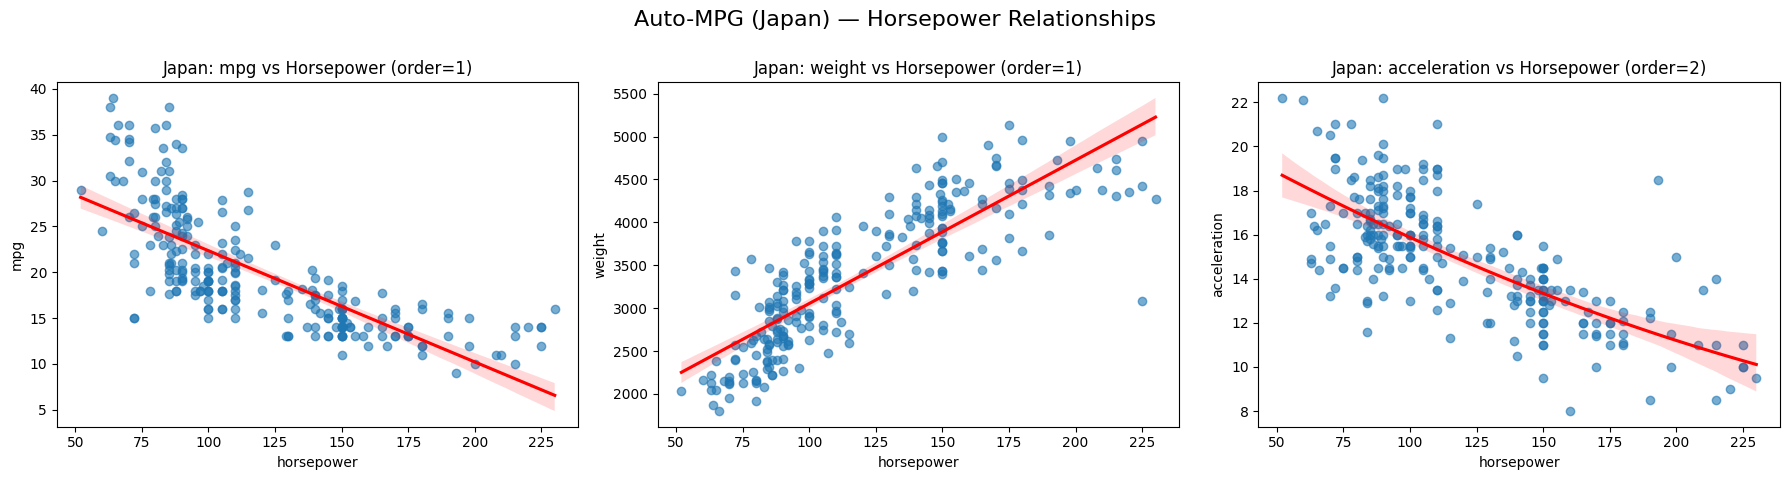

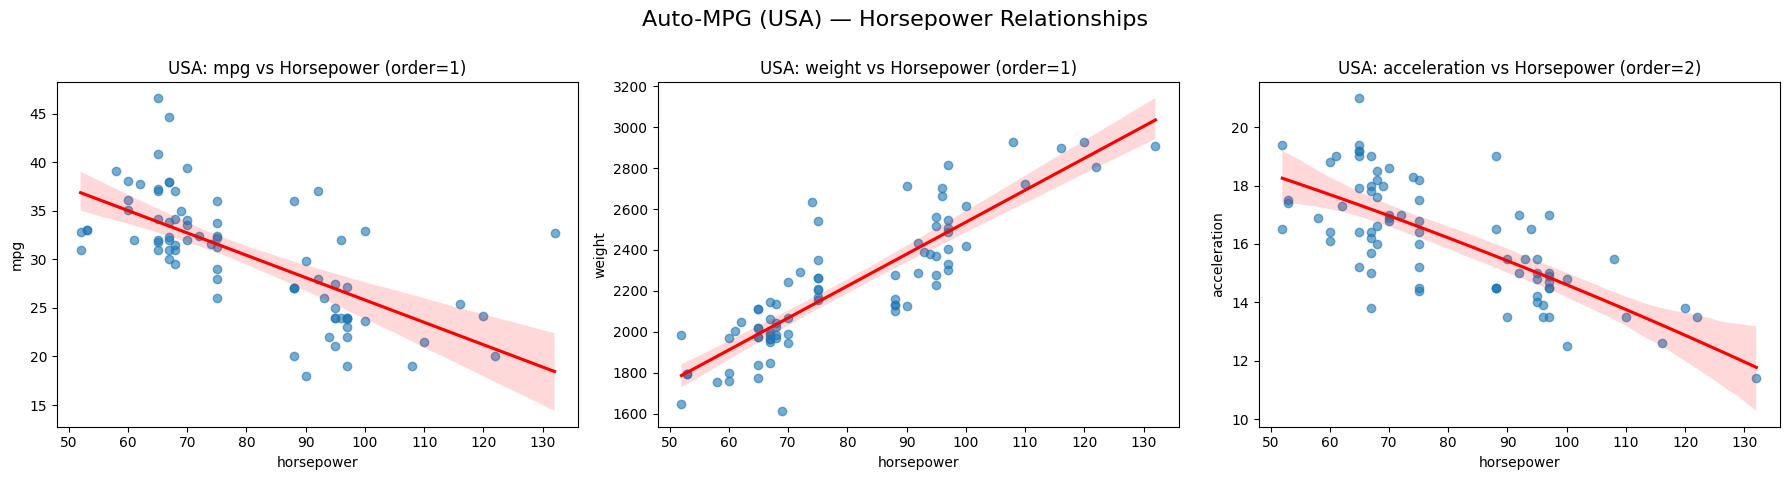

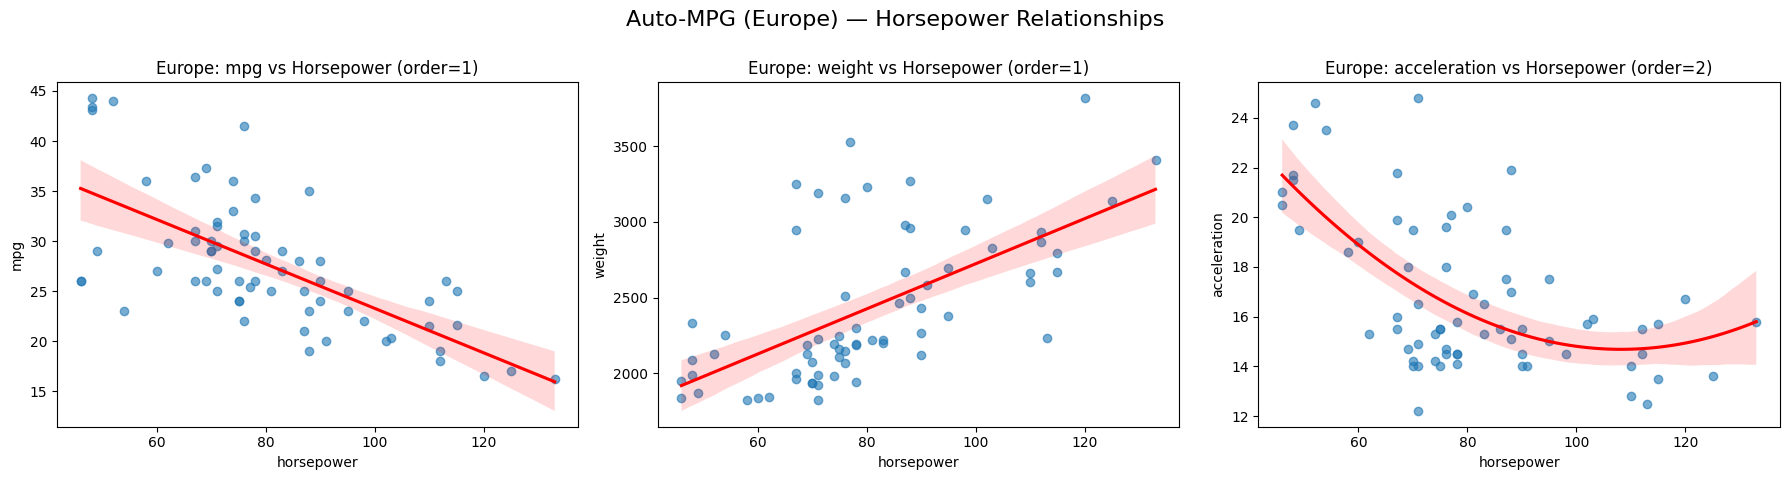

In [15]:
# Variables to plot
y_vars = ["mpg", "weight", "acceleration"]

# Loop through each origin
for origin in df["origin_label"].unique():
    subset = df[df["origin_label"] == origin]

    # Create 1x3 subplot grid for this origin
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes = axes.flatten()

    for i, y_var in enumerate(y_vars):
        # Use polynomial order=2 for acceleration, linear otherwise
        order_val = 2 if y_var == "acceleration" else 1

        sns.regplot(
            data=subset,
            x="horsepower",
            y=y_var,
            order=order_val,
            scatter_kws={'alpha':0.6},
            line_kws={'color':'red'},
            #x_estimator=np.mean,            
            ax=axes[i]
        )
        axes[i].set_title(f"{origin}: {y_var} vs Horsepower (order={order_val})")

    fig.suptitle(f"Auto-MPG ({origin}) — Horsepower Relationships", fontsize=16, y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#### 11.1 Horsepower Relationships by Region

- **USA**: 
    - mpg vs Horsepower: Strong negative linear relationship — higher horsepower sharply reduces mpg.
    - Weight vs Horsepower: Clear positive correlation — powerful engines paired with heavier cars.
    - Acceleration vs Horsepower: Negative quadratic trend — higher horsepower cars accelerate slower due to added weight.
    - USA emphasized large, powerful engines, sacrificing efficiency and agility

- **Europe**:
    - mpg vs Horsepower: Negative linear relationship — efficiency declines with horsepower, but less extreme than USA.
    - Weight vs Horsepower: Positive correlation — higher horsepower cars are heavier, though generally lighter than USA cars.
    - Acceleration vs Horsepower: Quadratic pattern — acceleration decreases with horsepower up to a point, then stabilizes or slightly improves.
    - Europe balanced compact efficiency with occasional mid-range horsepower designs for performance.

- **Japan**:
    - mpg vs Horsepower: Negative linear relationship — higher horsepower reduces mpg, but Japanese cars start with higher efficiency.
    - Weight vs Horsepower: Positive correlation — more horsepower linked to heavier cars, but overall weights remain lower than USA/Europe.
    - Acceleration vs Horsepower: Negative quadratic relationship — smaller, lighter cars with modest horsepower accelerate better.
    - Japan focused on lightweight, modest-horsepower cars, achieving high mpg and better agility compared to heavier, high-power models.


**USA** Power-focused, heavy cars → poor mpg and slower acceleration. **Europe** Balanced approach → moderate horsepower, lighter cars, efficiency maintained. **Japan** Efficiency-first → modest horsepower, lightweight cars, high mpg and agility

Across all regions, horsepower is tightly linked to fuel efficiency, weight, and acceleration trade-offs. USA leaned toward raw power, Europe balanced efficiency with moderate performance, and Japan led in efficiency with lightweight, agile designs.

#### 12. Visualization plot vehicle weight relates to other variables:


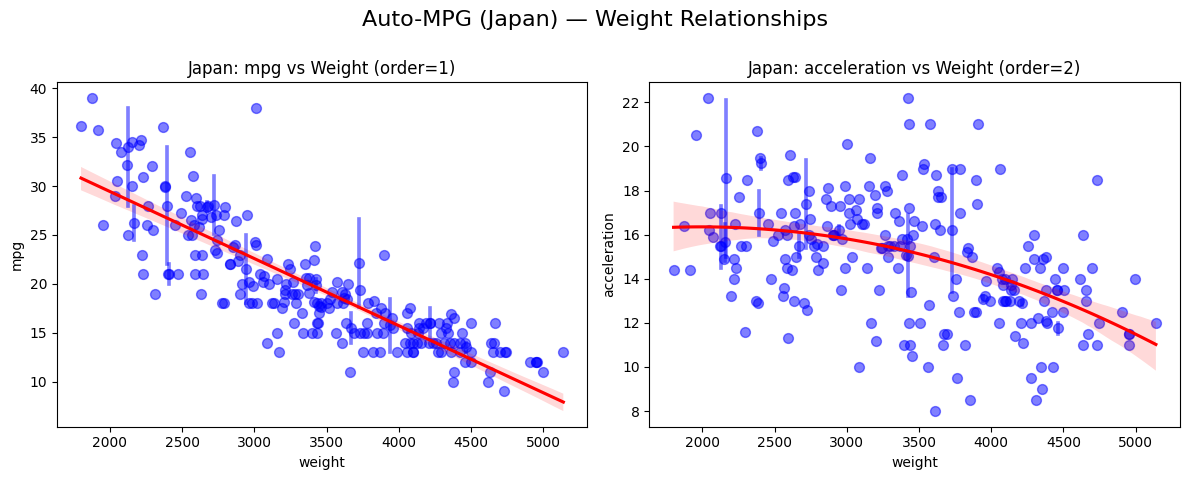

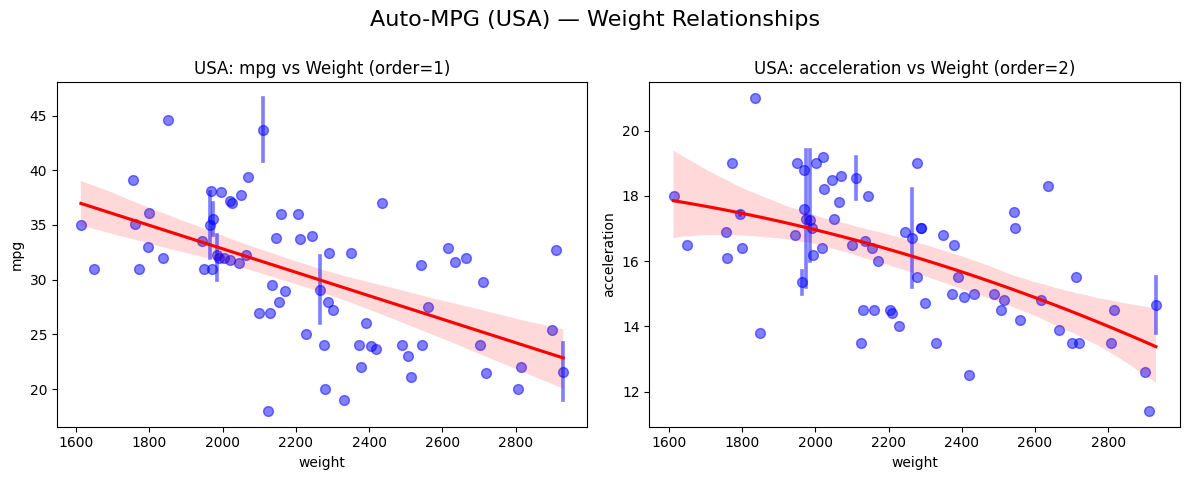

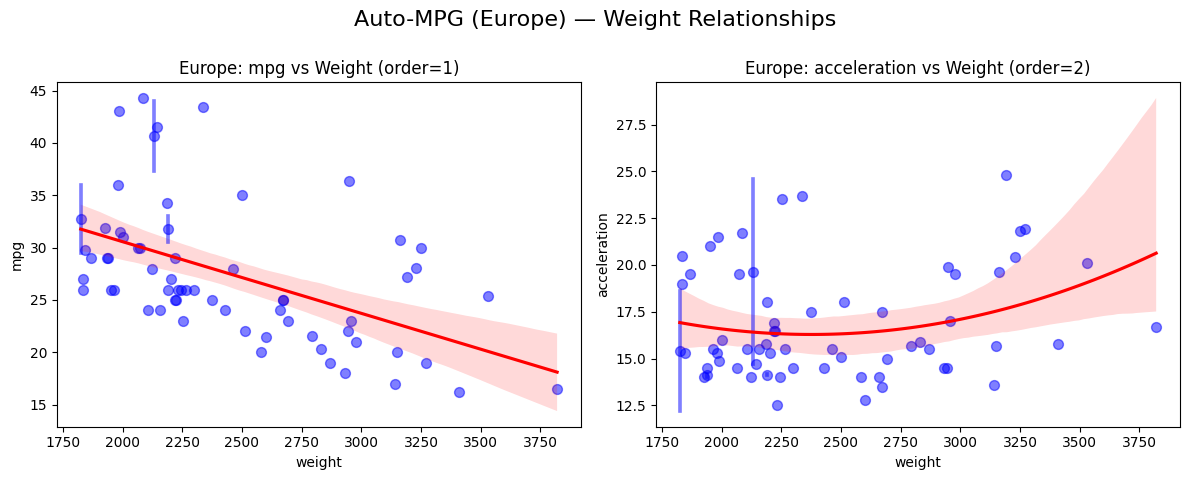

In [16]:
# Variables to plot
y_vars = ["mpg", "acceleration"]

# Loop through each origin
for origin in df["origin_label"].unique():
    subset = df[df["origin_label"] == origin]

    # Create 1x2 subplot grid for this origin (since 2 y_vars)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes = axes.flatten()

    for i, y_var in enumerate(y_vars):
        # Use polynomial order=2 for acceleration, linear otherwise
        order_val = 2 if y_var == "acceleration" else 1

        sns.regplot(
            data=subset,
            x="weight",
            y=y_var,
            order=order_val,
            scatter_kws={'alpha':0.5},
            x_estimator=np.mean,
            marker='o', # estimator marker
            color='blue', # estimator points in red
            line_kws={'color':'red'},
            ax=axes[i]            
        )
        axes[i].set_title(f"{origin}: {y_var} vs Weight (order={order_val})")

    fig.suptitle(f"Auto-MPG ({origin}) — Weight Relationships", fontsize=16, y=0.95)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#### 12.1 Visualization plot vehicle weight result analysis

- USA
    - mpg vs Weight: Strong negative linear relationship — heavier cars have lower mpg.
    - Acceleration vs Weight: Negative quadratic trend — heavier cars accelerate slower, losing agility.
    - USA leaned toward large, heavy vehicles, which reduced efficiency and performance balance.

- Europe
    - mpg vs Weight: Negative linear relationship — efficiency declines as weight increases.
    - Acceleration vs Weight: Quadratic pattern — lighter cars accelerate better, but some mid-to-heavy cars maintain reasonable performance due to design optimizations.
    - Europe emphasized compact, efficient cars, but engineered certain heavier models to balance performance.

- Japan
    - mpg vs Weight: Negative linear relationship — lighter cars achieve higher mpg.
    - Acceleration vs Weight: Negative quadratic trend — lighter cars accelerate better, heavier cars lose agility.
    - Japan strongly favored lightweight vehicles, achieving superior mpg and acceleration compared to heavier models.

- Comparative Summary:
    - USA: Heavy cars → poor mpg and slower acceleration.
    - Europe: Compact efficiency, with some heavier cars engineered for balanced performance.
    - Japan: Lightweight, efficiency-first design → high mpg and better agility


Across all regions, weight is a critical factor influencing fuel efficiency and acceleration. Japan led with lightweight efficiency, Europe balanced compactness with engineering optimizations, while USA lagged due to heavier, less efficient designs.

###  13. Final comparison across USA, Europe, and Japan:

**USA**: Early focus on large, cylinder-heavy, high-displacement engines → high horsepower but poor mpg. Cars were heavy, reducing acceleration and efficiency. Shift toward smaller, lighter 4-cylinder cars came later, driven by regulations and fuel crises.

**Europe**:  Maintained compact, moderate-displacement cars with balanced horsepower. Efficiency was consistently better than USA, though not as high as Japan.  Some heavier models were engineered to balance performance and efficiency.

**Japan**: Strong emphasis on lightweight, small-displacement, 4-cylinder cars. Achieved high mpg and better acceleration, even with modest horsepower. Led global efficiency trends, setting the benchmark for compact design

TODO Some anlysis

1. mpg (Miles per Gallon) Fuel efficiency:

$\mathrm{Fuel\ Consumption\ (L/100\ km)}=\frac{235.2}{\mathrm{mpg}}$

2. Displacement (cu. in.) Engine size (volume of cylinders)

$\mathrm{Displacement}=\frac{\pi }{4}\cdot \mathrm{Bore^{\mathnormal{2}}}\cdot \mathrm{Stroke}\cdot \mathrm{Number\ of\ Cylinders}$

3. Horsepower Engine output power:

$\mathrm{Horsepower}=\frac{\mathrm{Torque\ (lb-ft)}\times \mathrm{RPM}}{5252}$

4. Weight (lbs.) Vehicle mass:

$\mathrm{Force}=\mathrm{Mass}\cdot \mathrm{Acceleration}$

5. Acceleration (0–60 mph time) Vehicle performance

$a=\frac{\Delta v}{\Delta t}\mathrm{Acceleration}\propto \frac{\mathrm{Horsepower}}{\mathrm{Weight}}$

Derived Relationships in Auto-MPG Analysis:

Researchers often use multiple regression models to connect these variables:

#### Fuel Efficiency Model (empirical regression)

$mpg\approx \beta _0+\beta _1\cdot \frac{1}{weight}+\beta _2\cdot \frac{1}{horsepower}+\beta _3\cdot displacement+\epsilon$ 

- Shows how mpg decreases with higher weight/horsepower, and increases with smaller displacement.

#### Performance Model

$acceleration\approx \alpha _0+\alpha _1\cdot \frac{horsepower}{weight}+\alpha _2\cdot displacement+\epsilon$

- Captures how acceleration improves with higher horsepower-to-weight ratio.

#### Horsepower–Displacement Link

$horsepower\propto displacement^k$

- Empirical relationship: larger engines (higher displacement) tend to produce more horsepower



## 14. Multicollinearity Analysis

#### Why we drop the dependent variable in multicollinearity analysis

- Multicollinearity is only about predictors.
It measures how strongly independent variables are correlated with each other.
- The dependent variable (Y) is not part of the calculation because collinearity among predictors affects the stability of regression coefficients, not the relationship with Y.
- If you include Y in the analysis, you’re mixing two different concepts: predictor redundancy vs. predictive strength. That’s why we drop Y when computing VIF or correlation matrices for multicollinearity.


PCA vs. VIF in relation to Y

PCA:

Purely unsupervised. It maximizes variance in X, not correlation with Y. Sometimes the components that explain most variance in X are not the ones most predictive of Y. That’s why PCA is used for dimensionality reduction, not for direct prediction.

VIF:

Formula doesn’t use Y directly. But in practice, you compute VIF on the predictors you’ve chosen for a regression model with Y. The context of Y matters (because you care about coefficient stability in that model), but the math itself is only about X’s.


In [17]:
def tableDispFormatt(yourString):
    fixLen = 90
    startLine = '==============================='
    textLen = len(yourString)
    endLineLen = fixLen - (len(startLine)+textLen)
    endLine = ''
    for i in np.arange(0,endLineLen,1):
        endLine += '='
    print(startLine,yourString,endLine)

In [18]:
# Select numerical variables
X_un_scale_df = df[["displacement","horsepower","weight","acceleration","cylinders"]]
mColumns = X_un_scale_df.columns.values.tolist()
# --- Standard Scaler ---
scaler_std = StandardScaler()
X_std = scaler_std.fit_transform(X_un_scale_df)
X_std_df = pd.DataFrame(X_std, columns=X_un_scale_df.columns)

# --- MinMax Scaler ---
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X_un_scale_df)
X_mm_df = pd.DataFrame(X_mm, columns=X_un_scale_df.columns)

#### 14.1 Why We Need to Check for Multicollinearity in the Auto-MPG Dataset

#### 1. Background
The Auto-MPG dataset contains several predictor variables:
- Cylinders  
- Displacement  
- Horsepower  
- Weight  
- Acceleration  
- Model year  
- Origin  

Many of these variables are **highly correlated**. For example:
- `displacement`, `horsepower`, and `weight` often move together because larger engines tend to produce more horsepower and require heavier cars.  
- `cylinders` is strongly tied to `displacement` and `horsepower`.  
- `model year` is indirectly related to `mpg` because newer cars were designed to be more fuel efficient.

#### 2. What is Multicollinearity? and Why It Matters for Auto-MPG ?

Multicollinearity occurs when two or more predictor variables in a regression model are highly correlated.  
Inflated standard errors of coefficients, Unstable estimates (coefficients can change drastically with small data variations), Difficulty in interpreting the individual effect of each variable.

Since the dataset is often used to predict `mpg` (fuel efficiency), ignoring multicollinearity can cause:
- Misleading regression coefficients (e.g., displacement vs horsepower effects overlap)  
- Poor generalization to new data  
- Incorrect conclusions about which features truly drive fuel efficiency

#### Qus: How the multicollinearity create problem for linear regressions ?
 
In linear regression analysis parameter are the estimated by 

$\hat \beta = (X'X)^{-1} X'y$ ---- (i)

X'X is the square matrix and we are calculation inverse of square matrix. 

Now come to main point, Inverse matrix are Calculate by: 
Divide the adjoint matrix by the original determinant.

The formula for the inverse of a 2×2 matrix is:

$A^{-1}=\frac{1}{|A|}\cdot \mathrm{adj}(A)$ ; where |A| is the determinant.

You should focus on the determined part. for an example:

$A=\left[ \begin{matrix}a&b\\ c&d\end{matrix}\right] ,\quad |A|=ad-bc$

If the two columns of A are collinear (similar), then ad-bc\rightarrow 0.
This makes $|A|$ very small, and therefore $A^{-1}$ tends to $\infty$


Now from matrix A columns 1 and 2nd are similar or collinear then difference of product ad-bc have tendency to reach zero and $A^-1$ or ($(X'X)^-1$ in linear parameter estimations) tendency to approach $\infty$. 

#### Qus: So what happen if inverse parameter of square matrix $(X'X)^-1$ tends to $\infty$?

In regression, the variance of estimated coefficients is proportional to:

$Var(\hat {\beta })\propto (X'X)^{-1}$

If predictors are highly correlated, $X'X$ becomes nearly singular (determinant close to 0). This makes $(X'X)^{-1}$ unstable → variances of coefficients blow up.

Equations (1) become unstable. Coefficients become unstable (small changes in data cause large swings). Standard errors are inflated. Confidence intervals become very wide. Statistical significance tests (t-tests, p-values) become unreliable.

Remember that we have multiply transpose vector of X and make it square matrix. Because of  it is not possible to find a standard two-sided inverse for a non-square matrix. A standard inverse $A^{-1}$ is only defined for square matrices that are non-singular (having a non-zero determinant).


#### 14.2 Multicollinearity detections technique:

##### 14.2.1. Variance Inflation Factor (VIF):

**Definition:**  

Variance Inflation Factor (VIF) is a statistical measure used to detect the presence and severity of **multicollinearity** in regression analysis. It quantifies how much the variance of a regression coefficient is inflated due to linear dependence among predictor variables.

#### Calculations Variance Inflation Factor (VIF):

For predictor $X_j$, the VIF is defined as:

$C_{jj}=\frac{1}{1-R_j^2}$

$C_{jj}$ → diagonal element of the covariance matrix $(X'X)^{-1}$. $R_j^2$ → the coefficient of determination when regressing predictor $X_j$ on all other predictors.

So:

$VIF_j=C_{jj}=\frac{1}{1-R_j^2}$

where $R_j^2$ is the coefficient of determination when regressing $X_j$ on all the other predictors.

If $R_j^2$ is close to 1, it means predictor $X_j$ is highly explained by other predictors → strong multicollinearity. As $R_j^2\rightarrow 1$, the denominator $(1-R_j^2)$ becomes very small → $VIF_j$ becomes very large. A **large VIF indicates that the variance of the coefficient estimate for $X_j$ is inflated due to correlation with other predictors.**

VIF measures how much the variance of the estimated coefficient $\hat \beta_j$ is inflated due to multicollinearity


#### how multicollinearity is diagnosed and deal with using VIF (Variance Inflation Factor) ?

##### 14.2.1.1 Calculate  square root of the j‑th VIF

Qus: why we calculate square root of the j‑th VIF ?

Ans: The square root of the jth VIF indicates **how much longer the confidence interval** for the jth regression coefficient is because of multicollinearity. - The square root of the j‑th VIF gives the inflation factor of the standard error of $\hat {\beta }_j$.

$\sqrt{VIF_j}=\frac{\mathrm{SE\  with\  multicollinearity}}{\mathrm{SE\  without\  multicollinearity}}$

Please see another approch to understand the square root of the j‑th VIF

$\sqrt{VIF_j}=\sqrt{C_{jj}}=\frac{L_j}{L^*}$

Where:
- $VIF_j$ = Variance Inflation Factor for predictor $X_j$.
- $C_{jj}$ = diagonal element of the covariance matrix for coefficient $j$.
- $L_j$ = length of the confidence interval for coefficient $j$.
- $L^*$ = length of the confidence interval if predictors were orthogonal (uncorrelated)

##### 14.2.1.2 length of Confidence Interval:

The confidence interval length for coefficient $j$ is:

$L_j=2\cdot \sqrt{C_{jj}\cdot \sigma ^2}\cdot t_{\alpha /2,n-p-1}$

In an orthogonal design (no multicollinearity), the interval length is:

$L^*=2\cdot \sigma \cdot t_{\alpha /2,n-p-1}$
- Therefore:
$\sqrt{VIF_j}=\frac{L_j}{L^*}$

$\sqrt{VIF_j}$ tells how much **longer the confidence interval for coefficient** $j$ is compared to the ideal case with no multicollinearity.

Take Example:
If $\sqrt{VIF_j}=2$, the confidence interval for $\beta _j$ is $twice$ as wide as it would be in an orthogonal design.

If $\sqrt{VIF_j}=5$, the interval is five times wider.

This directly links multicollinearity to loss of precision in estimating coefficients

#### 14.2.1.3 Final conclusions:

Large $\sqrt{VIF_j}$ means your **coefficient estimates are unstable and less reliable**. Even if the predictor is theoretically important, high multicollinearity makes it hard to distinguish its unique effect. This is why **thresholds like VIF > 10 (or equivalently $\sqrt{VIF}>3.16$)** are **often used to flag problematic predictors**

- Interpretation:
    - VIF = 1–5 → Low correlation, safe.
    - VIF = 5–10 → Moderate correlation, caution.
    - VIF > 10 → High multicollinearity, problematic.

- Square root of VIF → tells you how much wider the confidence interval for $\hat \beta _j$ is compared to an orthogonal design (no correlation).



        feature     VIF_raw  VIF_standard_scaled  VIF_minmax_scaled
0  displacement   73.478856            19.535061          47.240658
1    horsepower   43.979332             8.916017          15.424389
2        weight  137.439120            10.430271          34.382682
3  acceleration   27.833437             2.609487           3.385731
4     cylinders  101.859772            10.630870          31.739118
=============================== interpret VIF values with standard scaled ==================
        feature  VIF_standard_scaled                        Interpretation
0  displacement            19.535061  High multicollinearity (Problematic)
1    horsepower             8.916017        Moderate correlation (Caution)
2        weight            10.430271  High multicollinearity (Problematic)
3  acceleration             2.609487                Low correlation (Safe)
4     cylinders            10.630870  High multicollinearity (Problematic)


=============================== Comparison of V

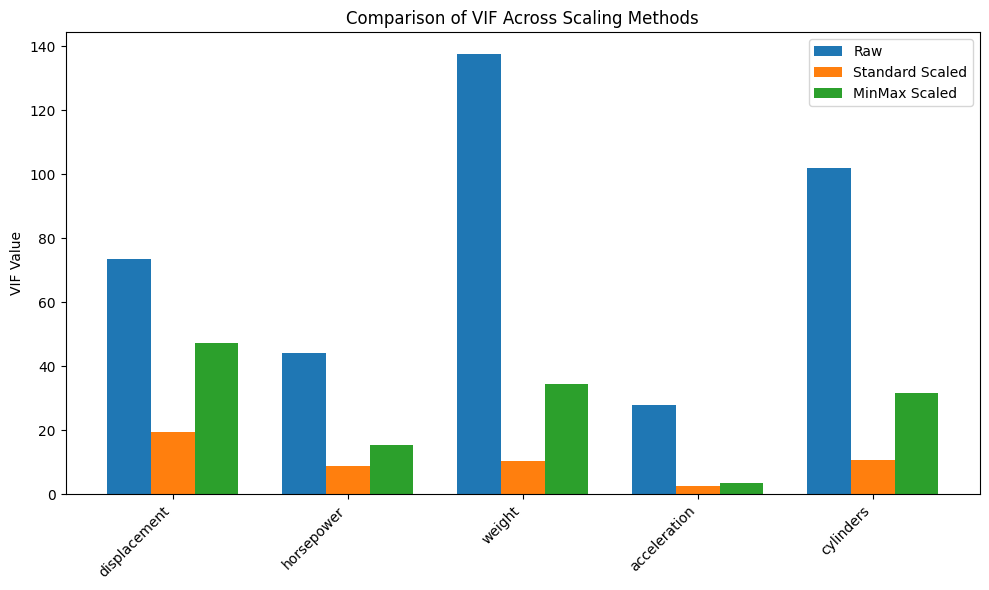

In [19]:
def compute_vif(dataframe):
    vif_data = pd.DataFrame()
    vif_data["feature"] = dataframe.columns
    vif_data["VIF"] = [variance_inflation_factor(dataframe.values, i) 
                       for i in range(dataframe.shape[1])]
    return vif_data

# Without scaling
vif_raw = compute_vif(X_un_scale_df)

# With standard scaling
vif_scaled_std = compute_vif(X_std_df)

# With min max scaling
vif_scaled_min_max = compute_vif(X_mm_df)


vif_combined = pd.DataFrame({
    "feature": vif_raw["feature"],
    "VIF_raw": vif_raw["VIF"],
    "VIF_standard_scaled": vif_scaled_std["VIF"],
    "VIF_minmax_scaled": vif_scaled_min_max["VIF"]
})

print(vif_combined)

# Function to interpret VIF values
def interpret_vif(vif_value):
    if vif_value < 5:
        return "Low correlation (Safe)"
    elif 5 <= vif_value <= 10:
        return "Moderate correlation (Caution)"
    else:
        return "High multicollinearity (Problematic)"

# Create new DataFrame with interpretations for VIF_standard_scaled
vif_interpretation = pd.DataFrame({
    "feature": vif_combined["feature"],
    "VIF_standard_scaled": vif_combined["VIF_standard_scaled"],
    "Interpretation": vif_combined["VIF_standard_scaled"].apply(interpret_vif)
})
tableDispFormatt('interpret VIF values with standard scaled')
print(vif_interpretation)

print('\n')
tableDispFormatt('Comparison of VIF Across Scaling and non-Scaling Methods')
# Plot VIF comparison
fig, ax = plt.subplots(figsize=(10,6))

features = vif_combined["feature"]
x = range(len(features))

ax.bar([i-0.25 for i in x], vif_combined["VIF_raw"], width=0.25, label="Raw")
ax.bar(x, vif_combined["VIF_standard_scaled"], width=0.25, label="Standard Scaled")
ax.bar([i+0.25 for i in x], vif_combined["VIF_minmax_scaled"], width=0.25, label="MinMax Scaled")

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha="right")
ax.set_ylabel("VIF Value")
ax.set_title("Comparison of VIF Across Scaling Methods")
ax.legend()

plt.tight_layout()
plt.show()

The comparison of VIF values across raw, standardized, and min‑max scaled data shows that scaling dramatically reduces inflated multicollinearity measures. In the raw dataset, VIF values were excessively high due to differences in variable magnitudes. After applying StandardScaler, the VIF values dropped to stable and interpretable levels, making it the most effective approach for diagnosing multicollinearity. MinMaxScaler also reduced VIF values compared to raw data, but not as effectively as standardization. This confirms that scaling—especially standardization—is essential before applying VIF in datasets like Auto‑MPG to obtain reliable results.

#### 14.2.2. Eigen vector address multi-collinearity:

#### 14.2.3 Eigen vector how to address multi collinearity ?

Multicollinearity and Eigenvalues In regression, the correlation structure of predictors can be studied using the eigenvalues (characteristic roots) of the matrix X'X or the correlation matrix of predictors. Small eigenvalues (close to zero) indicate that some predictors are nearly linear combinations of others → this is multicollinearity. The smaller the eigenvalue, the stronger the dependency among predictors.


$\mathrm{Multicollinearity\  severity}\; \alpha \; \propto \frac{1}{\lambda }$\
$\lambda$  = eigenvalue of the predictor correlation matrix.

$\lambda$  is very small, then $\frac{1}{\lambda }$ becomes very large → strong multicollinearity.

#### 14.2.3. Condition Number and Condition Indices in Eigenvalues:

When analyzing multicollinearity using eigenvalues of the predictor matrix $X'$X:

$\kappa =\frac{\lambda _{\mathrm{max}}}{\lambda _{\mathrm{min}}}$
- $\kappa$  = Condition Number
- $\lambda _{\mathrm{max}}$ = largest eigenvalue
- $\lambda _{\mathrm{min}}$ = smallest eigenvalue


In [20]:
# --- Functions ---
def cond_correlation(df):
    return np.linalg.cond(df.corr())

def cond_covariance(df):
    return np.linalg.cond(np.cov(df.T))

def cond_design(df):
    X = np.column_stack([np.ones(df.shape[0]), df.values])  # add intercept
    return np.linalg.cond(X)

def interpret_condition_number(value):
    if value < 10:
        return "Safe (Low correlation)"
    elif 10 <= value <= 30:
        return "Moderate correlation (Caution)"
    else:
        return "High multicollinearity (Problematic)"

# --- Compute condition numbers ---
results = []

for method, data in {
    "Raw (Unscaled)": X_un_scale_df,
    "Standard Scaled": X_std_df,
    "MinMax Scaled": X_mm_df
}.items():
    corr_val = cond_correlation(data)
    cov_val = cond_covariance(data)
    design_val = cond_design(data)

    results.append({
        "Scaling Method": method,
        "Correlation Matrix": corr_val,
        "Correlation Interpretation": interpret_condition_number(corr_val),
        "Covariance Matrix": cov_val,
        "Covariance Interpretation": interpret_condition_number(cov_val),
        "Design Matrix": design_val,
        "Design Interpretation": interpret_condition_number(design_val)
    })

# --- Create DataFrame ---
cond_summary = pd.DataFrame(results)

#print(cond_summary)

cond_summary = pd.DataFrame(results)

# --- Color-coded highlighting ---
def highlight_interpretation(val):
    if "Safe" in val:
        return "background-color: lightgreen"
    elif "Moderate" in val:
        return "background-color: khaki"
    elif "High" in val:
        return "background-color: lightcoral"
    return ""

styled_summary = cond_summary.style.map(highlight_interpretation, subset=[
    "Correlation Interpretation",
    "Covariance Interpretation",
    "Design Interpretation"
])

styled_summary


,Scaling Method,Correlation Matrix,Correlation Interpretation,Covariance Matrix,Covariance Interpretation,Design Matrix,Design Interpretation
0,Raw (Unscaled),111.504346,High multicollinearity (Problematic),2676285.521370,High multicollinearity (Problematic),38745.127738,High multicollinearity (Problematic)
1,Standard Scaled,111.504346,High multicollinearity (Problematic),111.504346,High multicollinearity (Problematic),10.559562,Moderate correlation (Caution)
2,MinMax Scaled,111.504346,High multicollinearity (Problematic),101.333011,High multicollinearity (Problematic),26.150221,Moderate correlation (Caution)


#### 14.2.3. Difference between using correlation, covariance, and the design matrix for condition number analysis:

*Why the condition number from the correlation matrix is identical ?*

- A correlation matrix is scale‑invariant: it standardizes each variable by its variance before computing correlations.
- Whether you use raw values, StandardScaler, or MinMaxScaler, the correlation structure between variables remains the same.
- Because the correlation matrix doesn’t change with scaling, the condition number is identical across all scaling methods.
That’s why you saw the same value (~111.50) for raw, standardized, and min‑max scaled data.

*Covariance matrix and design matrix* condition numbers are the meaningful diagnostics: they show how scaling improves numerical stability and reduces multicollinearity. Among the methods, StandardScaler gives the most satisfactory results — condition numbers drop to safe levels, making regression analysis reliable.


This unified table makes it crystal clear:
- Correlation matrix → same across scaling, always problematic.
- Covariance matrix → scaling helps but still problematic.
- Design matrix → StandardScaler gives safe results, MinMaxScaler is cautionary, raw is problematic.


#### 14.2.4. Principal Component Analysis (PCA) and Multicollinearity

Principal Component Analysis (PCA) can be viewed as a powerful technique to **address multicollinearity** in a dataset.  
Instead of working directly with the original, often correlated variables, PCA transforms them into a new set of **uncorrelated variables** called *principal components*.  

- Each principal component is a **linear combination** of the original variables.  
- The components are ordered by importance:  
  - The **first principal component** captures the maximum possible variance in the data.  
  - Subsequent components explain progressively smaller amounts of variance, while remaining orthogonal (uncorrelated) to the previous ones.  

By using principal components as predictors in regression models, we reduce redundancy among variables, stabilize coefficient estimates, and improve interpretability.  
This makes PCA especially useful when dealing with datasets like Auto‑MPG, where variables such as displacement, horsepower, and weight are highly correlated.

While we won't dive into the formal mathematical derivations of PCA here, we will walk through the step-by-step implementation to understand how it transforms our correlated features into principal components.

Step 1: Find the variance–covariance matrix of dataset: for an example

The variance–covariance matrix of the data is:

$\Sigma =\left[ \begin{matrix}2.879368&10.01&-1.80905\\ 10.01&199.7884&-5.64\\ -1.80905&-5.64&3.627658\end{matrix}\right]$ 

Step 2:The eigenvalues and eigenvectors of this matrix, arranged in decreasing order of eigenvalues, are:

- $\lambda _1=200.462, with\ eigenvector\ a_1=(0.0508,0.9983,-0.0291)$
- $\lambda _2=4.532, with eigenvector a_2=(-0.5737,0.0530,0.8173)$
- $\lambda _3=1.301, with eigenvector a_3=(0.8175,-0.0249,0.5754)$

Step 3:The principal components are linear combinations of the original variables $x_1,x_2,x_3$:

$z_1=0.0508x_1+0.9983x_2-0.0291x_3$

$z_2=-0.5737x_1+0.0530x_2+0.8173x_3$

$z_3=0.8175x_1-0.0249x_2+0.5754x_3$

where $z_1,z_2,z_3$ are the principal component.

*Note: The variance of principal components will be eigenvalues*

The variance of the principal components is equal to the eigenvalues:

$\mathrm{Var}(z_1)=200.462,\quad \mathrm{Var}(z_2)=4.532,\quad \mathrm{Var}(z_3)=1.301$

The total variation explained by the principal components is:

$\lambda _1+\lambda _2+\lambda _3=200.462+4.532+1.301=206.295$

Step 4: Calculate proportion of total variation accounted for by the principal component

The proportion of total variation accounted for by the first principal component is

$\frac{\lambda _1}{\lambda _1+\lambda _2+\lambda _3}=\frac{200.462}{206.295}=0.9717\quad \mathrm{of\  the\  total\  variance}$

The proportion of total variance explained by the first two principal components is:

$\frac{\lambda _1+\lambda _2}{\lambda _1+\lambda _2+\lambda _3}=\frac{204.994}{206.295}=0.9937\quad \mathrm{of\  the\  total\  variance}$

Hence, in further analysis, the first one or two principal components ($Z_1$ and $Z_2$) can effectively replace the original three variables while sacrificing only a negligible amount of information about the total variation in the system. The loss of information is:
$1-0.9937=0.0063\approx 0.63\%$
This means that by excluding the third component, we retain over 99% of the variance. Such a reduction demonstrates the essence of dimensionality reduction: simplifying the dataset by removing redundant variables while preserving nearly all of the meaningful information.

Step 5: Finally calculate your PC component:

Let from your Dataset variables are

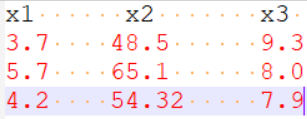

On the basis of given data your corresponding principal component are the

For ($x_1,x_2,x_3$)=(3.7,48.5,9.3):

- $z_1$=0.0508(3.7)+0.9983(48.5)-0.0291(9.3) = 0.18796+48.44155-0.27063 $\approx$ 48.36
- $z_2$=-0.5737(3.7)+0.0530(48.5)+0.8173(9.3) = -2.12269+2.5705+7.60089 $\approx$ 8.05
- $z_3$=0.8175(3.7)-0.0249(48.5)+0.5754(9.3) = 3.025-1.20865+5.35422 $\approx$ 7.17

For ($x_1,x_2,x_3$)=(5.7,65.1,8.0):

- $z_1$=0.0508(5.7)+0.9983(65.1)-0.0291(8.0) = 0.28956+64.98933-0.2328 $\approx$ 65.05
- $z_2$=-0.5737(5.7)+0.0530(65.1)+0.8173(8.0) = -3.269+3.4503+6.5384 $\approx$ 6.72
- $z_3$=0.8175(5.7)-0.0249(65.1)+0.5754(8.0) = 4.660-1.620+4.603 $\approx$ 7.64

For ($x_1,x_2,x_3$)=(4.2,54.32,7.9):

- $z_1$=0.0508(4.2)+0.9983(54.32)-0.0291(7.9) = 0.21336+54.22714-0.22989 $\approx$ 54.21
- $z_2$=-0.5737(4.2)+0.0530(54.32)+0.8173(7.9) = -2.40954+2.8790+6.46067 $\approx$ 6.93
- $z_3$=0.8175(4.2)-0.0249(54.32)+0.5754(7.9) = 3.434+-1.353+4.544 $\approx$ 6.63

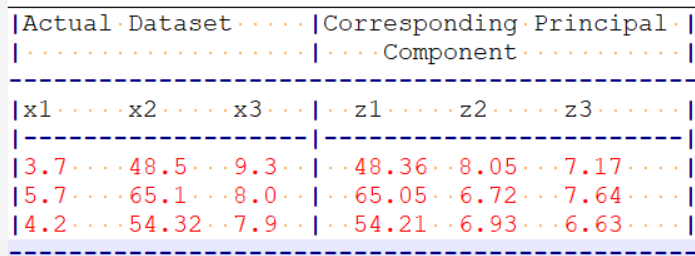

The Auto-MPG dataset contains the following variables:

mpg, cylinders, displacement, horsepower, weight, acceleration, model year, origin, and car name.

Among these, the categorical variables are model year, origin, and car name. For the investigation of multicollinearity, I will focus only on the numerical variables.
To detect multicollinearity in the dataset, I plan to use three statistical techniques:
- Variance Inflation Factor (VIF)
- Principal Component Analysis (PCA)
- Condition Number of the Eigenvalue Matrix
It is important to note that multicollinearity can be strongly influenced by whether the data is scaled or unscaled. Therefore, part of the analysis will involve comparing the detection of multicollinearity with scaling and without scaling, to understand how scaling affects the results.

In [21]:
# Step by step PCA analysis
# return ProjectedData,PCA,PCA_variance,X_mean
def pca_step_by_step(X_centered, n_components):
    # Step 1: Standardize the data     
    # Standardize the data (mean=0, variance=1)        
    # Step 2: Compute the covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)
    
    # Step 3: Compute the eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

    # Step 4: Sort the eigenvalues and eigenvectors
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    # Step 5: Select the first n_components principle component eigenvectors
    PCs = sorted_eigenvectors[:, :n_components]*-1    
    # Step 6: Projected Data
    X_principal_component = np.dot(X_centered, PCs)
    # Step 7: Return the projected data, PCs, eigenvalues, and mean
    return X_principal_component, PCs, sorted_eigenvalues[:n_components]

# PCA by using numpy svd
def pca_from_svd(X_centered):
    # Step 1: Standardize the data
    #print('pca_from_svd is set to True, standardizing the data')
       
    # Step 2: Perform Singular Value Decomposition (SVD)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    # U: left singular vectors
    # S: singular values
    # Vt: right singular vectors (principal component directions)
    # Step 3: Select the first n_components principal components
    # Eigenvalues from singular values
    eigenvalues = (S**2) / (X_centered.shape[0] - 1)
    # Explained variance ratio
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    Cumulative_variance      = np.cumsum(explained_variance_ratio)
    PCs = Vt.T
    # Transform data (scores);Project the data onto the principal components
    X_pca = np.dot(X_centered, PCs)
    
    return X_pca, PCs, explained_variance_ratio, Cumulative_variance

# PCA by using sklearn
def pca_from_PCA_scaled(X_scaled, columns, n_components: int = 2):
    """
    Apply PCA to already scaled data.
    
    Parameters:
        X_scaled (ndarray): Pre-scaled numeric data (e.g., from StandardScaler).
        columns (list): Names of the original features (for loadings).
        n_components (int): Number of principal components to compute.
    
    Returns:
        explained_variance_ratio (array): Variance explained by each PC.
        components (pd.DataFrame): PCA loadings (linear combinations).
        X_pca (ndarray): Transformed data in PC space.
    """
    # Apply PCA directly
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    # Variance ratio
    explained_variance_ratio = pca.explained_variance_ratio_

    # Components (loadings)
    components = pd.DataFrame(
        pca.components_,
        columns=columns,
        index=[f"PC{i+1}" for i in range(n_components)]
    )

    return explained_variance_ratio, components, X_pca

def plot_variance_ratio(variance_ratio,title_str):
    """
    Plot explained variance ratio for PCA components with annotations.
    """
    n_components = len(variance_ratio)
    x = np.arange(1, n_components + 1)

    plt.figure(figsize=(8,5))
    bars = plt.bar(x, variance_ratio, color="orange", edgecolor="black")

    # Add cumulative variance line
    plt.plot(x, np.cumsum(variance_ratio), marker="o", color="red", label="Cumulative Variance")

    # Annotate each bar with its value
    for bar, val in zip(bars, variance_ratio):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=9)

    plt.xticks(x, [f"PC{i}" for i in x])
    plt.ylabel("Explained Variance Ratio")
    plt.xlabel("Principal Components")
    plt.title(f"Explained Variance Ratio by {title_str}")
    plt.legend()
    plt.tight_layout()
    plt.show()

=============================== pca apply min-max scaler ===================================
Explained Variance Ratio: [0.88064951 0.07085767 0.03013616 0.00966601 0.00869065]

PCA Components (loadings):
      displacement  horsepower    weight  acceleration  cylinders
PC1      0.503132    0.365320  0.431056     -0.180338   0.628545
PC2      0.057003   -0.350971  0.258604      0.868185   0.230104
PC3     -0.064224   -0.445979 -0.578460     -0.177725   0.656335
PC4     -0.214527    0.736721 -0.465543      0.403270   0.178503
PC5      0.832744   -0.041302 -0.442683      0.139711  -0.298906


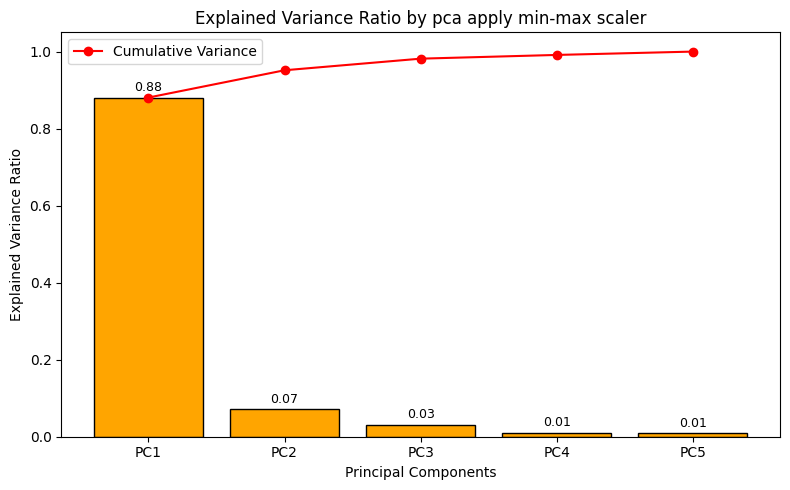

=============================== pca apply standerd scaler ==================================
Explained Variance Ratio: [0.81437196 0.13877225 0.02669861 0.01285368 0.0073035 ]

PCA Components (loadings):
      displacement  horsepower    weight  acceleration  cylinders
PC1      0.482404    0.473844  0.461790     -0.331379   0.468717
PC2      0.178630   -0.119989  0.345286      0.885736   0.223479
PC3      0.187640   -0.627571 -0.334497     -0.158656   0.658700
PC4     -0.021241   -0.593599  0.703244     -0.282071  -0.270319
PC5      0.836491   -0.121940 -0.247158      0.030387  -0.472655


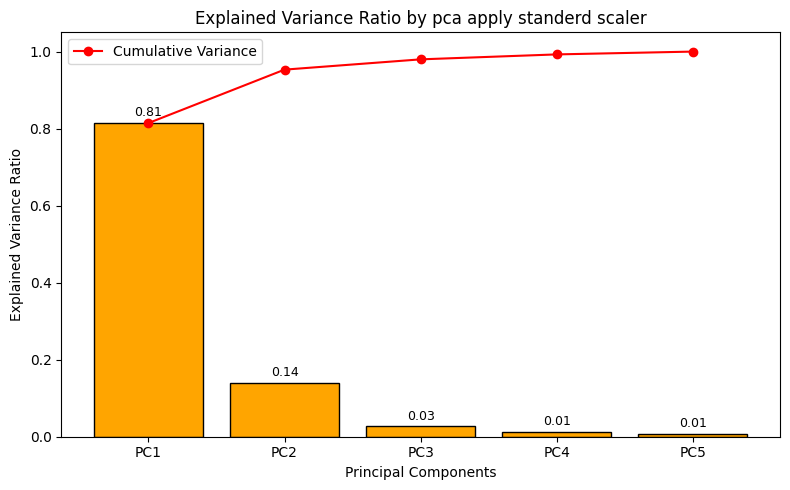

=============================== pca apply un-scaled data ===================================
Explained Variance Ratio: [9.97578746e-01 2.06165051e-03 3.55273905e-04 3.95643084e-06
 3.72747503e-07]

PCA Components (loadings):
      displacement  horsepower    weight  acceleration  cylinders
PC1      0.114341    0.038967  0.992674     -0.001353   0.001793
PC2      0.946116    0.298150 -0.120754     -0.034828   0.013330
PC3     -0.302440    0.950006 -0.002548     -0.077196  -0.007288
PC4      0.010042    0.084016 -0.003067      0.996269  -0.016686
PC5     -0.014857    0.004283 -0.000240      0.016532   0.999744


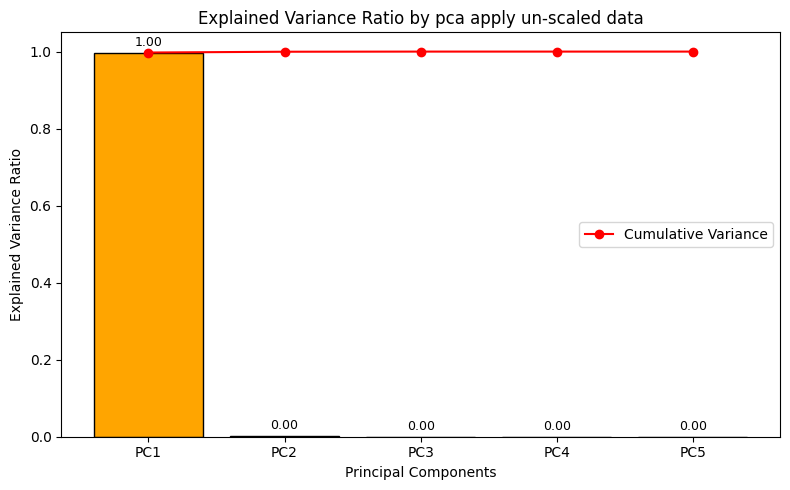

In [22]:
# --- Example usage ---
# Assume X_scaled is already created using StandardScaler
# and df is your original DataFrame

variance_ratio, pca_components, X_pca = pca_from_PCA_scaled(X_scaled = X_mm_df,
            columns = mColumns, n_components=X_mm_df.shape[1])
tableDispFormatt('pca apply min-max scaler')
print("Explained Variance Ratio:", variance_ratio)
print("\nPCA Components (loadings):\n", pca_components)
plot_variance_ratio(variance_ratio,'pca apply min-max scaler')
# print("\nFirst 5 transformed rows (PC scores):\n", X_pca[:5])

variance_ratio, pca_components, X_pca = pca_from_PCA_scaled(X_scaled = X_std_df,
            columns = mColumns, n_components=X_std_df.shape[1])
tableDispFormatt('pca apply standerd scaler')
print("Explained Variance Ratio:", variance_ratio)
print("\nPCA Components (loadings):\n", pca_components)
plot_variance_ratio(variance_ratio,'pca apply standerd scaler')
# print("\nFirst 5 transformed rows (PC scores):\n", X_pca[:5])
# print("\nFirst 5 transformed rows (PC scores):\n", X_pca[:5])
variance_ratio, pca_components, X_pca = pca_from_PCA_scaled(X_scaled = X_un_scale_df,
            columns = mColumns, n_components=X_un_scale_df.shape[1])
tableDispFormatt('pca apply un-scaled data')
print("Explained Variance Ratio:", variance_ratio)
print("\nPCA Components (loadings):\n", pca_components)
plot_variance_ratio(variance_ratio,'pca apply un-scaled data')
# print("\nFirst 5 transformed rows (PC scores):\n", X_pca[:5])

#### 14.2.4.1 PCA result analysis

#### Min–Max Scaler

- PC1 explains ~88% of the variance, with the remaining components contributing very little.
- This indicates one dominant axis of variation, but the distribution is slightly skewed because Min–Max scaling compresses values into [0,1] without equalizing variance.
- Result: Good, but not optimal — later PCs don’t capture meaningful structure.

#### Standard Scaler
- PC1 explains ~81%, PC2 ~14%, PC3 ~3%, and the rest negligible.
- This is the most balanced outcome: variance is spread across multiple components, showing that PCA is capturing meaningful multidimensional structure.
- Result: Best (perfect) result — StandardScaler equalizes variance across features, so PCA can correctly identify directions of maximum variance.

#### Unscaled Data
- PC1 explains ~100% of the variance, all others are ~0.
- This happens because features with larger numeric ranges dominate the covariance matrix.
- PCA is essentially “blind” to smaller‑scale variables, collapsing everything into one axis.
- Result: Misleading — PCA fails to capture the true structure.


#### PCA is sensitive to scaling.
Because PCA relies on variance and covariance, features measured on larger scales dominate the principal components if you don’t scale.
#### Scaling is necessary for PCA.
StandardScaler is generally the best choice because it standardizes each feature to zero mean and unit variance, ensuring all variables contribute equally to the analysis. The Standard Scaler result is the most reliable: it distributes variance across multiple components, avoids domination by a single variable, and reveals the underlying structure of the dataset

Standard Scaler gives the most trustworthy PCA: variance is distributed across PCs, showing real multidimensional structure. Min–Max Scaler is acceptable but less balanced. Unscaled data is misleading: PCA collapses everything into one axis because large‑scale variables dominate.

This demonstrates that PCA is sensitive to scaling. Without scaling, PCA ignores smaller‑scale variables. With proper scaling (especially StandardScaler), PCA reveals the true underlying structure.

#### 14.2.4.2. Final Conclusions from PCA (Standard Scaler):

Using the Standard Scaler, the principal component analysis shows:
- PC1 accounts for 81% of the total variation.
- PC2 accounts for 14%.
- PC3 accounts for 3%.

Together, PC1 + PC2 + PC3 explain 98% of the total variation in the dataset. This means that nearly all of the information is captured by the first three components, and the remaining components (PC4, PC5, etc.) contribute negligibly. Dropping them results in only a minimal loss of information.
In the Auto MPG dataset, the first three principal components are strongly associated with displacement, horsepower, and weight. These variables alone capture about 98% of the information related to fuel consumption, making them the dominant drivers of variation in the dataset.

PCA with Standard Scaler distributes variance meaningfully across multiple components. The first three PCs are sufficient to represent the dataset with minimal information loss. This highlights how PCA can reduce dimensionality while preserving nearly all of the explanatory power of the original variables.